# 1. Setup & Config

In [1]:
!pip install -q datasets transformers accelerate

In [16]:
import os
import re
import gc
import copy
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

SAVE_DIR = "/kaggle/working/saved_models"
RESULT_DIR = "/kaggle/working/results"
DATA_DIR = "/kaggle/working/data"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [17]:
aspect_list = [
    "SCREEN",
    "CAMERA",
    "FEATURES",
    "BATTERY",
    "PERFORMANCE",
    "STORAGE",
    "DESIGN",
    "PRICE",
    "GENERAL",
    "SER&ACC"
]

label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
    "not_mentioned": 3
}

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive",
    3: "not_mentioned"
}

label_order = ["Negative", "Neutral", "Positive", "not_mentioned"]

# 2. Load and Explore ViSFD

In [18]:
dataset = load_dataset("visolex/ViSFD")
dataset

README.md: 0.00B [00:00, ?B/s]

ViSFD.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/11122 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['dataset', 'type', 'index', 'comment', 'n_star', 'date_time', 'label'],
        num_rows: 11122
    })
})

In [19]:
df = dataset["train"].to_pandas().copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (11122, 7)


,dataset,type,index,comment,n_star,date_time,label
0,UIT-ViSFD,train,0,Mới mua máy này Tại thegioididong thốt nốt cảm...,5,2 tuần trước,{CAMERA#Positive};{FEATURES#Positive};{BATTERY...
1,UIT-ViSFD,train,1,Pin kém còn lại miễn chê mua 8/3/2019 tình trạ...,5,14/09/2019,{BATTERY#Negative};{GENERAL#Positive};{OTHERS};
2,UIT-ViSFD,train,2,Sao lúc gọi điện thoại màn hình bị chấm nhỏ nh...,3,17/08/2020,{FEATURES#Negative};
3,UIT-ViSFD,train,3,"Mọi người cập nhật phần mềm lại , nó sẽ bớt tố...",3,29/02/2020,{FEATURES#Negative};{BATTERY#Neutral};{GENERAL...
4,UIT-ViSFD,train,4,"Mới mua Sài được 1 tháng thấy pin rất trâu, Sà...",5,4/6/2020,{BATTERY#Positive};{PERFORMANCE#Positive};{SER...


In [20]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11122 entries, 0 to 11121
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   dataset    11122 non-null  object
 1   type       11122 non-null  object
 2   index      11122 non-null  int64 
 3   comment    11122 non-null  object
 4   n_star     11122 non-null  int64 
 5   date_time  11122 non-null  object
 6   label      11122 non-null  object
dtypes: int64(2), object(5)
memory usage: 608.4+ KB
None

Missing values:
dataset      0
type         0
index        0
comment      0
n_star       0
date_time    0
label        0
dtype: int64


In [21]:
for i in range(3):
    print(f"Sample {i}")
    print("COMMENT:", df.loc[i, "comment"])
    print("LABEL  :", df.loc[i, "label"])
    print("-" * 100)

Sample 0
COMMENT: Mới mua máy này Tại thegioididong thốt nốt cảm thấy ok bin trâu chụp ảnh đẹp loa nghe to bắt wf khỏe sóng ổn định, giá thành vừa với túi tiền, nhân viên tư vấn nhiệt tình
LABEL  : {CAMERA#Positive};{FEATURES#Positive};{BATTERY#Positive};{PRICE#Positive};{GENERAL#Positive};{SER&ACC#Positive};
----------------------------------------------------------------------------------------------------
Sample 1
COMMENT: Pin kém còn lại miễn chê mua 8/3/2019 tình trạng pin còn 88% có ai giống tôi không
LABEL  : {BATTERY#Negative};{GENERAL#Positive};{OTHERS};
----------------------------------------------------------------------------------------------------
Sample 2
COMMENT: Sao lúc gọi điện thoại màn hình bị chấm nhỏ nháy gần camera trước vậy(lúc có lúc không)
LABEL  : {FEATURES#Negative};
----------------------------------------------------------------------------------------------------


Star rating distribution:
n_star
1    1831
2     829
3    1426
4    1851
5    5185
Name: count, dtype: int64


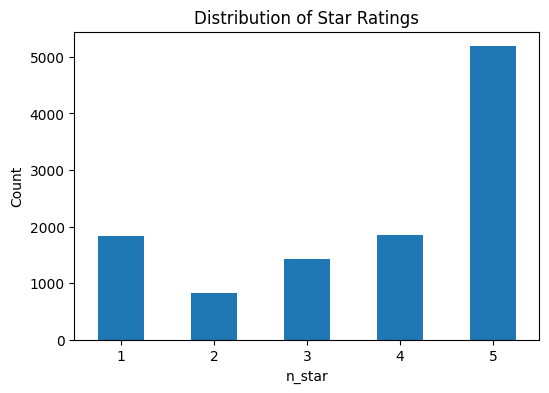

In [23]:
print("Star rating distribution:")
print(df["n_star"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df["n_star"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Star Ratings")
plt.xlabel("n_star")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 3. Parse ABSA Labels

In [24]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [25]:
def parse_label_string(label_str, aspect_list):
    aspect_sentiments = {aspect: "not_mentioned" for aspect in aspect_list}
    
    matches = re.findall(r"\{([^#{}]+)#([^{}]+)\}", str(label_str))
    
    for aspect, sentiment in matches:
        aspect = aspect.strip()
        sentiment = sentiment.strip()
        
        if aspect in aspect_list:
            aspect_sentiments[aspect] = sentiment
    
    return aspect_sentiments

In [26]:
df["text_clean"] = df["comment"].apply(clean_text)

parsed = df["label"].apply(lambda x: parse_label_string(x, aspect_list))
parsed_df = pd.DataFrame(parsed.tolist())

parsed_df.head()

,SCREEN,CAMERA,FEATURES,BATTERY,PERFORMANCE,STORAGE,DESIGN,PRICE,GENERAL,SER&ACC
0,not_mentioned,Positive,Positive,Positive,not_mentioned,not_mentioned,not_mentioned,Positive,Positive,Positive
1,not_mentioned,not_mentioned,not_mentioned,Negative,not_mentioned,not_mentioned,not_mentioned,not_mentioned,Positive,not_mentioned
2,not_mentioned,not_mentioned,Negative,not_mentioned,not_mentioned,not_mentioned,not_mentioned,not_mentioned,not_mentioned,not_mentioned
3,not_mentioned,not_mentioned,Negative,Neutral,not_mentioned,not_mentioned,not_mentioned,not_mentioned,Neutral,not_mentioned
4,not_mentioned,not_mentioned,not_mentioned,Positive,Positive,not_mentioned,not_mentioned,not_mentioned,not_mentioned,Negative


In [27]:
for aspect in aspect_list:
    df[aspect] = parsed_df[aspect]
    df[f"{aspect}_id"] = df[aspect].map(label2id)

df[["text_clean"] + [f"{a}_id" for a in aspect_list]].head()

,text_clean,SCREEN_id,CAMERA_id,FEATURES_id,BATTERY_id,PERFORMANCE_id,STORAGE_id,DESIGN_id,PRICE_id,GENERAL_id,SER&ACC_id
0,mới mua máy này tại thegioididong thốt nốt cảm...,3,2,2,2,3,3,3,2,2,2
1,pin kém còn lại miễn chê mua 8/3/2019 tình trạ...,3,3,3,0,3,3,3,3,2,3
2,sao lúc gọi điện thoại màn hình bị chấm nhỏ nh...,3,3,0,3,3,3,3,3,3,3
3,"mọi người cập nhật phần mềm lại , nó sẽ bớt tố...",3,3,0,1,3,3,3,3,1,3
4,"mới mua sài được 1 tháng thấy pin rất trâu, sà...",3,3,3,2,2,3,3,3,3,0


In [ ]:
for aspect in aspect_list:
    missing = df[f"{aspect}_id"].isnull().sum()
    print(f"{aspect}_id missing:", missing)

SCREEN_id missing: 0
CAMERA_id missing: 0
FEATURES_id missing: 0
BATTERY_id missing: 0
PERFORMANCE_id missing: 0
STORAGE_id missing: 0
DESIGN_id missing: 0
PRICE_id missing: 0
GENERAL_id missing: 0
SER&ACC_id missing: 0


# 4. Label Distribution + Visualization

In [29]:
distribution_table = pd.DataFrame()

for aspect in aspect_list:
    counts = df[aspect].value_counts().reindex(label_order, fill_value=0)
    distribution_table[aspect] = counts

distribution_table = distribution_table.T
distribution_table

SCREEN,Negative,Neutral,Positive,not_mentioned
SCREEN,542,85,712,9783
CAMERA,886,395,1749,8092
FEATURES,2351,283,1100,7388
BATTERY,1746,492,2884,6000
PERFORMANCE,2160,552,3182,5228
STORAGE,29,15,88,10990
DESIGN,438,117,1408,9159
PRICE,431,1608,843,8240
GENERAL,1370,407,5159,4186
SER&ACC,732,147,1999,8244


In [30]:
distribution_percent = distribution_table.div(distribution_table.sum(axis=1), axis=0) * 100
distribution_percent.round(2)

SCREEN,Negative,Neutral,Positive,not_mentioned
SCREEN,4.87,0.76,6.40,87.96
CAMERA,7.97,3.55,15.73,72.76
FEATURES,21.14,2.54,9.89,66.43
BATTERY,15.70,4.42,25.93,53.95
PERFORMANCE,19.42,4.96,28.61,47.01
STORAGE,0.26,0.13,0.79,98.81
DESIGN,3.94,1.05,12.66,82.35
PRICE,3.88,14.46,7.58,74.09
GENERAL,12.32,3.66,46.39,37.64
SER&ACC,6.58,1.32,17.97,74.12


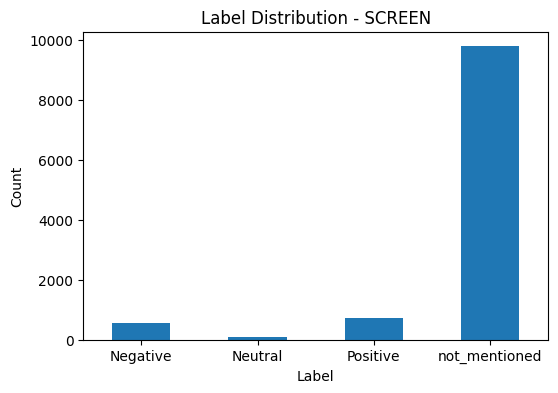

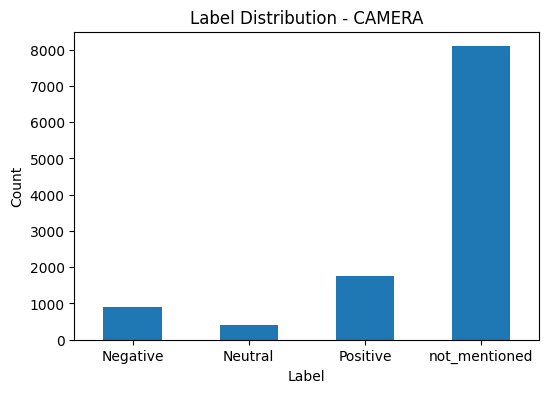

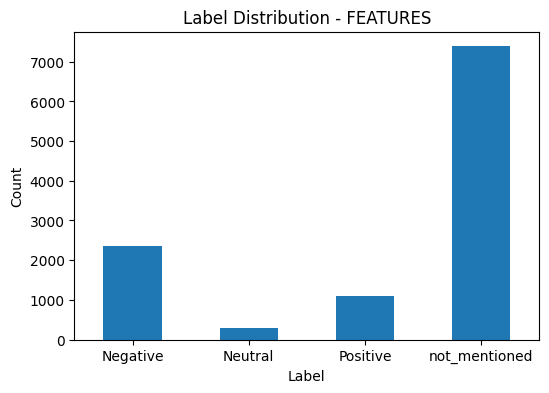

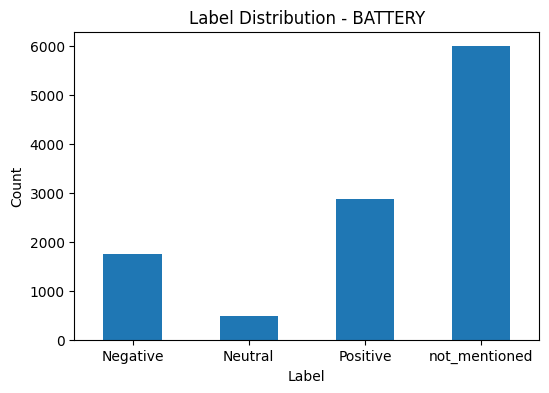

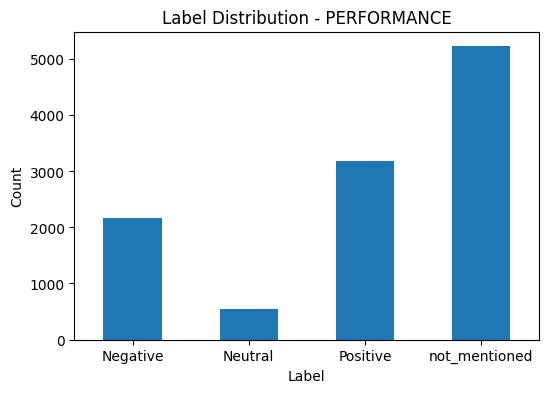

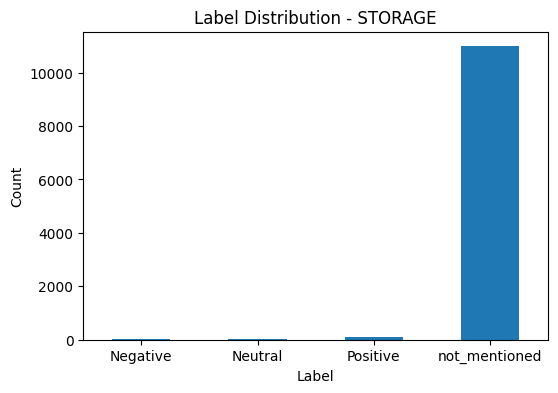

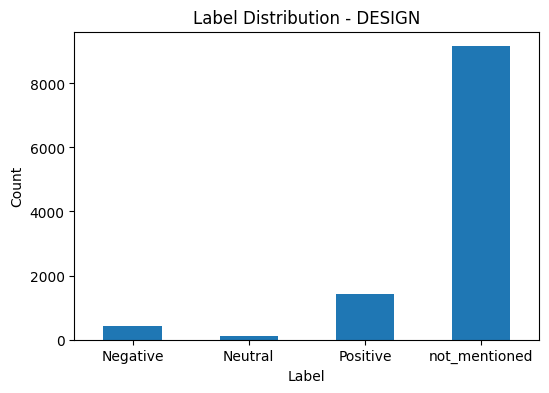

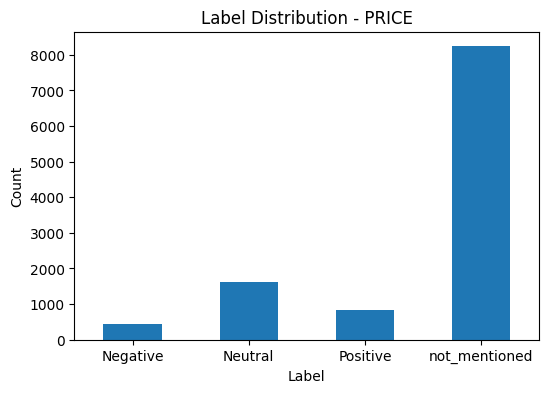

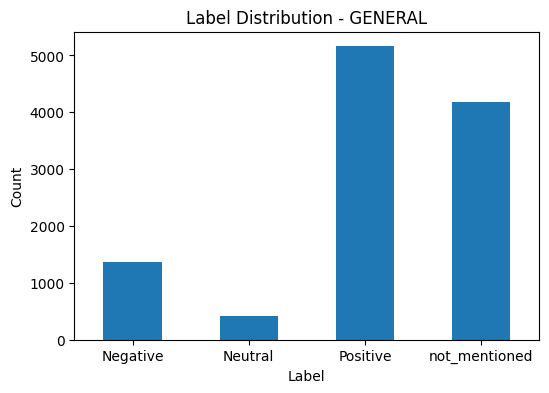

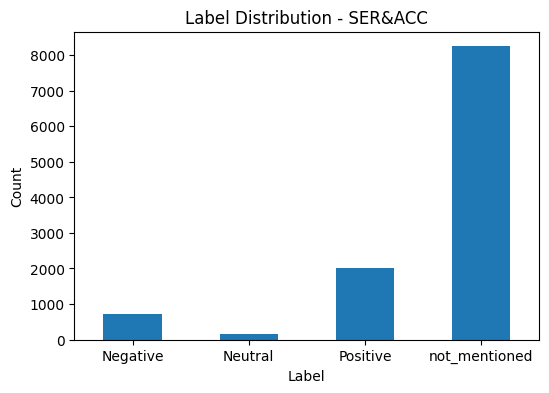

In [31]:
for aspect in aspect_list:
    plt.figure(figsize=(6, 4))
    df[aspect].value_counts().reindex(label_order, fill_value=0).plot(kind="bar")
    plt.title(f"Label Distribution - {aspect}")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

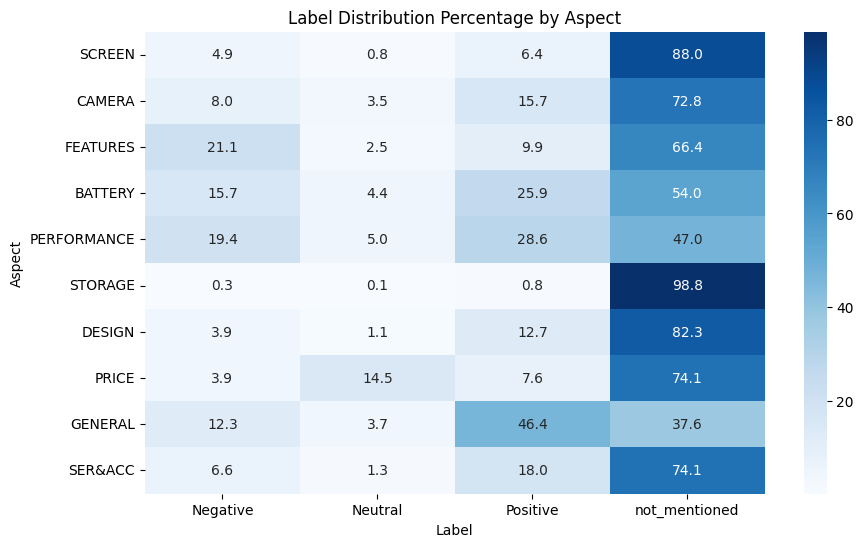

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    distribution_percent.round(2),
    annot=True,
    fmt=".1f",
    cmap="Blues"
)
plt.title("Label Distribution Percentage by Aspect")
plt.xlabel("Label")
plt.ylabel("Aspect")
plt.show()

# 5. Train / Validation / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

keep_cols = ["text_clean"] + [f"{aspect}_id" for aspect in aspect_list]

df_split = df[keep_cols].copy()
df_split["stratify_col"] = df["GENERAL_id"].astype(str)

train_temp, test_prepared = train_test_split(
    df_split,
    test_size=0.15,
    random_state=SEED,
    stratify=df_split["stratify_col"]
)

train_prepared, val_prepared = train_test_split(
    train_temp,
    test_size=0.1765,
    random_state=SEED,
    stratify=train_temp["stratify_col"]
)
 
train_prepared = train_prepared[keep_cols].reset_index(drop=True)
val_prepared = val_prepared[keep_cols].reset_index(drop=True)
test_prepared = test_prepared[keep_cols].reset_index(drop=True)

print("Train shape:", train_prepared.shape)
print("Validation shape:", val_prepared.shape)
print("Test shape:", test_prepared.shape)

for aspect in aspect_list:
    print("\nAspect:", aspect)
    print("Train:")
    print(train_prepared[f"{aspect}_id"].value_counts().sort_index())
    print("Validation:")
    print(val_prepared[f"{aspect}_id"].value_counts().sort_index())
    print("Test:")
    print(test_prepared[f"{aspect}_id"].value_counts().sort_index())

Train shape: (7784, 11)
Validation shape: (1669, 11)
Test shape: (1669, 11)

Aspect: SCREEN
Train:
SCREEN_id
0     367
1      59
2     515
3    6843
Name: count, dtype: int64
Validation:
SCREEN_id
0      90
1      11
2     100
3    1468
Name: count, dtype: int64
Test:
SCREEN_id
0      85
1      15
2      97
3    1472
Name: count, dtype: int64

Aspect: CAMERA
Train:
CAMERA_id
0     635
1     282
2    1193
3    5674
Name: count, dtype: int64
Validation:
CAMERA_id
0     113
1      60
2     273
3    1223
Name: count, dtype: int64
Test:
CAMERA_id
0     138
1      53
2     283
3    1195
Name: count, dtype: int64

Aspect: FEATURES
Train:
FEATURES_id
0    1639
1     205
2     741
3    5199
Name: count, dtype: int64
Validation:
FEATURES_id
0     350
1      38
2     184
3    1097
Name: count, dtype: int64
Test:
FEATURES_id
0     362
1      40
2     175
3    1092
Name: count, dtype: int64

Aspect: BATTERY
Train:
BATTERY_id
0    1235
1     339
2    2016
3    4194
Name: count, dtype: int64
Validati

In [34]:
print(train_prepared.columns)
train_prepared.head()

Index(['text_clean', 'SCREEN_id', 'CAMERA_id', 'FEATURES_id', 'BATTERY_id',
       'PERFORMANCE_id', 'STORAGE_id', 'DESIGN_id', 'PRICE_id', 'GENERAL_id',
       'SER&ACC_id'],
      dtype='object')


,text_clean,SCREEN_id,CAMERA_id,FEATURES_id,BATTERY_id,PERFORMANCE_id,STORAGE_id,DESIGN_id,PRICE_id,GENERAL_id,SER&ACC_id
0,mình vừa mua được 3 ngày xài thấy cũng ok nhưn...,3,3,0,0,3,3,3,3,2,3
1,cho em hỏi là tại sao chụp ảnh nó bị mờ không ...,3,0,3,0,3,3,3,3,2,3
2,"sử dụng được 1 tuần. cảm biến vân tay nhạy, qu...",3,1,2,2,3,3,3,3,2,3
3,máy sạc pin quá chậm mất 5 tiếng để sạc đầy pi...,3,3,3,0,1,3,3,3,3,3
4,không có hiển thị phần trăm pin à. xin hướng d...,3,3,0,3,3,3,3,1,2,3


In [35]:
# =========================================================
# SAVE SPLIT DATA
# =========================================================

train_prepared.to_csv(f"{DATA_DIR}/train_prepared.csv", index=False)
val_prepared.to_csv(f"{DATA_DIR}/val_prepared.csv", index=False)
test_prepared.to_csv(f"{DATA_DIR}/test_prepared.csv", index=False)

print("Saved train/val/test CSV files.")

Saved train/val/test CSV files.


# 6. Baseline Experiments

In [22]:
import joblib

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

label_ids = [0, 1, 2, 3]
label_names = ["Negative", "Neutral", "Positive", "not_mentioned"]

# 6.1 Oversampling Function

In [ ]:
def custom_rebalance_train_for_aspect(
    train_df,
    aspect,
    sentiment_increase_pct=0.5,
    not_mentioned_ratio=2.0,
    random_state=42
):
    target = f"{aspect}_id"
    df_temp = train_df.copy()

    value_counts = df_temp[target].value_counts()

    not_mentioned_pct = value_counts.get(3, 0) / len(df_temp)

    if not_mentioned_pct > 0.95:
        print(f"[SKIP OVERSAMPLING] {aspect} is too sparse. Use original train data.")
        return df_temp.sample(frac=1, random_state=random_state).reset_index(drop=True)

    parts = []

    # Tăng nhẹ các class sentiment: Negative, Neutral, Positive
    for label in [0, 1, 2]:
        df_cls = df_temp[df_temp[target] == label]

        if len(df_cls) == 0:
            continue

        target_n = int(len(df_cls) * (1 + sentiment_increase_pct))

        sampled_cls = df_cls.sample(
            n=target_n,
            replace=True,
            random_state=random_state
        )

        parts.append(sampled_cls)

    df_sentiment = pd.concat(parts, axis=0)
    sentiment_total = len(df_sentiment)


    df_nm = df_temp[df_temp[target] == 3]
    nm_target = int(sentiment_total * not_mentioned_ratio)

    min_nm_keep = int(len(df_nm) * 0.5)
    nm_target = max(nm_target, min_nm_keep)

    if len(df_nm) > nm_target:
        df_nm = df_nm.sample(
            n=nm_target,
            replace=False,
            random_state=random_state
        )

    parts.append(df_nm)

    df_balanced = pd.concat(parts, axis=0)
    df_balanced = df_balanced.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return df_balanced

# 6.2 METRIC FUNCTION - FIX MACRO F1 WITH ALL LABELS

In [25]:
import joblib

In [26]:
# =========================================================
# 6.2 METRIC FUNCTION - FIX MACRO F1 WITH ALL LABELS
# =========================================================

def compute_baseline_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=label_ids,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1
    }

# 6.3 BASELINE TRAINING FUNCTION

In [27]:
# =========================================================
# 6.3 BASELINE TRAINING FUNCTION
# =========================================================

def build_baseline_model(model_name, use_class_weight=False):
    if model_name == "logreg":
        clf = LogisticRegression(
            max_iter=1000,
            class_weight="balanced" if use_class_weight else None,
            random_state=SEED
        )

    elif model_name == "svm":
        clf = LinearSVC(
            class_weight="balanced" if use_class_weight else None,
            random_state=SEED
        )

    else:
        raise ValueError("model_name must be 'logreg' or 'svm'")

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9
        )),
        ("clf", clf)
    ])

    return model


def train_baseline_one_aspect(
    train_df,
    val_df,
    aspect,
    model_name="logreg",
    use_class_weight=False
):
    target_col = f"{aspect}_id"

    model = build_baseline_model(
        model_name=model_name,
        use_class_weight=use_class_weight
    )

    model.fit(train_df["text_clean"], train_df[target_col])

    y_true = val_df[target_col]
    y_pred = model.predict(val_df["text_clean"])

    metrics = compute_baseline_metrics(y_true, y_pred)

    metrics.update({
        "aspect": aspect,
        "model": model_name,
        "use_class_weight": use_class_weight
    })

    return model, metrics

# 6.4 RUN BASELINE EXPERIMENTS

In [28]:
# =========================================================
# 6.4 RUN BASELINE EXPERIMENTS
# =========================================================

all_baseline_results = []
baseline_models = {}

baseline_configs = [
    {
        "round": "R1_logreg",
        "model_name": "logreg",
        "use_oversampling": False,
        "use_class_weight": False
    },
    {
        "round": "R2_logreg_class_weight",
        "model_name": "logreg",
        "use_oversampling": False,
        "use_class_weight": True
    },
    {
        "round": "R3_logreg_oversampling",
        "model_name": "logreg",
        "use_oversampling": True,
        "use_class_weight": False
    },
    {
        "round": "R4_logreg_oversampling_class_weight",
        "model_name": "logreg",
        "use_oversampling": True,
        "use_class_weight": True
    },
    {
        "round": "R5_svm",
        "model_name": "svm",
        "use_oversampling": False,
        "use_class_weight": False
    },
    {
        "round": "R6_svm_class_weight",
        "model_name": "svm",
        "use_oversampling": False,
        "use_class_weight": True
    }
]

for cfg in baseline_configs:
    round_name = cfg["round"]

    for aspect in aspect_list:
        print("=" * 80)
        print(f"Training {round_name} - {aspect}")

        if cfg["use_oversampling"]:
            train_used = custom_rebalance_train_for_aspect(
                train_prepared,
                aspect,
                sentiment_increase_pct=0.5,
                not_mentioned_ratio=2.0,
                random_state=SEED
            )

            before = train_prepared[f"{aspect}_id"].value_counts().sort_index()
            after = train_used[f"{aspect}_id"].value_counts().sort_index()

            compare_dist = pd.DataFrame({
                "before": before,
                "after": after
            }).fillna(0).astype(int)

            print(f"\nDistribution before vs after - {aspect}")
            print(compare_dist)

        else:
            train_used = train_prepared.copy()

        model, result = train_baseline_one_aspect(
            train_used,
            val_prepared,
            aspect,
            model_name=cfg["model_name"],
            use_class_weight=cfg["use_class_weight"]
        )

        result["round"] = round_name
        result["use_oversampling"] = cfg["use_oversampling"]

        all_baseline_results.append(result)
        baseline_models[(aspect, round_name)] = model


baseline_all_df = pd.DataFrame(all_baseline_results)
baseline_all_df

Training R1_logreg - SCREEN
Training R1_logreg - CAMERA
Training R1_logreg - FEATURES
Training R1_logreg - BATTERY
Training R1_logreg - PERFORMANCE
Training R1_logreg - STORAGE
Training R1_logreg - DESIGN
Training R1_logreg - PRICE
Training R1_logreg - GENERAL
Training R1_logreg - SER&ACC
Training R2_logreg_class_weight - SCREEN
Training R2_logreg_class_weight - CAMERA
Training R2_logreg_class_weight - FEATURES
Training R2_logreg_class_weight - BATTERY
Training R2_logreg_class_weight - PERFORMANCE
Training R2_logreg_class_weight - STORAGE
Training R2_logreg_class_weight - DESIGN
Training R2_logreg_class_weight - PRICE
Training R2_logreg_class_weight - GENERAL
Training R2_logreg_class_weight - SER&ACC
Training R3_logreg_oversampling - SCREEN

Distribution before vs after - SCREEN
           before  after
SCREEN_id               
0             367    550
1              59     88
2             515    772
3            6843   3421
Training R3_logreg_oversampling - CAMERA

Distribution befor

,accuracy,macro_precision,macro_recall,macro_f1,aspect,model,use_class_weight,round,use_oversampling
0,0.905932,0.589400,0.386523,0.435880,SCREEN,logreg,False,R1_logreg,False
1,0.866986,0.754074,0.530010,0.568764,CAMERA,logreg,False,R1_logreg,False
2,0.817855,0.614249,0.487231,0.518258,FEATURES,logreg,False,R1_logreg,False
3,0.843020,0.873859,0.623298,0.626026,BATTERY,logreg,False,R1_logreg,False
4,0.758538,0.648310,0.567623,0.566525,PERFORMANCE,logreg,False,R1_logreg,False
5,0.982624,0.245803,0.250000,0.247884,STORAGE,logreg,False,R1_logreg,False
6,0.883763,0.594862,0.386434,0.415156,DESIGN,logreg,False,R1_logreg,False
7,0.855003,0.830485,0.532979,0.580874,PRICE,logreg,False,R1_logreg,False
8,0.769922,0.737562,0.567135,0.586242,GENERAL,logreg,False,R1_logreg,False
9,0.892750,0.659803,0.480035,0.515235,SER&ACC,logreg,False,R1_logreg,False


# 6.4 Compare Baseline Rounds

In [29]:
# =========================================================
# 6.5 COMPARE BASELINE ROUNDS
# =========================================================

compare_baseline_f1 = baseline_all_df.pivot(
    index="aspect",
    columns="round",
    values="macro_f1"
)

score_cols = list(compare_baseline_f1.columns)

compare_baseline_f1["best_round"] = compare_baseline_f1[score_cols].idxmax(axis=1)
compare_baseline_f1["best_macro_f1"] = compare_baseline_f1[score_cols].max(axis=1)

compare_baseline_f1 = compare_baseline_f1.sort_values(
    "best_macro_f1",
    ascending=False
)

compare_baseline_f1.columns.name = None
compare_baseline_f1

,R1_logreg,R2_logreg_class_weight,R3_logreg_oversampling,R4_logreg_oversampling_class_weight,R5_svm,R6_svm_class_weight,best_round,best_macro_f1
aspect,,,,,,,,
PRICE,0.580874,0.742831,0.593582,0.749350,0.696621,0.735827,R4_logreg_oversampling_class_weight,0.749350
CAMERA,0.568764,0.700256,0.572515,0.690995,0.675259,0.705073,R6_svm_class_weight,0.705073
BATTERY,0.626026,0.699495,0.620791,0.694670,0.686548,0.702595,R6_svm_class_weight,0.702595
GENERAL,0.586242,0.666894,0.576889,0.636064,0.623290,0.630723,R2_logreg_class_weight,0.666894
PERFORMANCE,0.566525,0.648137,0.576304,0.630090,0.603107,0.631858,R2_logreg_class_weight,0.648137
FEATURES,0.518258,0.594949,0.525596,0.575592,0.572650,0.597421,R6_svm_class_weight,0.597421
SER&ACC,0.515235,0.583146,0.521366,0.594334,0.559277,0.565275,R4_logreg_oversampling_class_weight,0.594334
SCREEN,0.435880,0.573116,0.463296,0.556762,0.574742,0.584772,R6_svm_class_weight,0.584772
DESIGN,0.415156,0.569548,0.462448,0.565439,0.536536,0.567967,R2_logreg_class_weight,0.569548


In [30]:
round_summary = (
    baseline_all_df
    .groupby("round")["macro_f1"]
    .mean()
    .reset_index()
    .sort_values("macro_f1", ascending=False)
)

round_summary

,round,macro_f1
1,R2_logreg_class_weight,0.625428
3,R4_logreg_oversampling_class_weight,0.616920
5,R6_svm_class_weight,0.608080
4,R5_svm,0.587229
2,R3_logreg_oversampling,0.516067
0,R1_logreg,0.506084


# 6.5 Baseline Visualizations

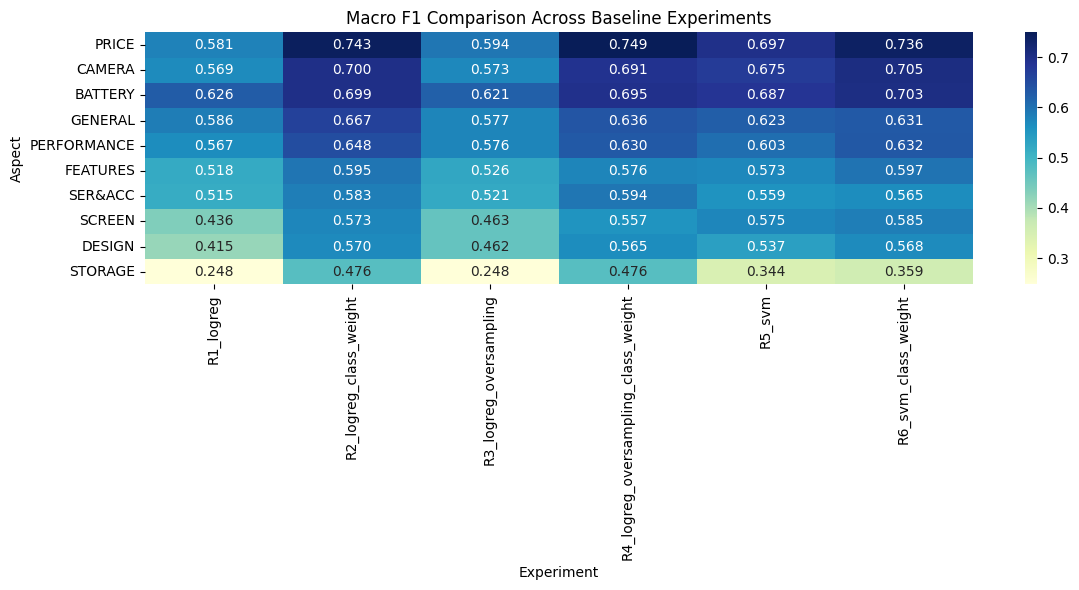

In [32]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    compare_baseline_f1[score_cols],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Macro F1 Comparison Across Baseline Experiments")
plt.xlabel("Experiment")
plt.ylabel("Aspect")
plt.tight_layout()
plt.show()

# 6.6 Save Baseline Results

In [33]:
# =========================================================
# 6.7 SAVE BASELINE RESULTS AND BEST MODELS
# =========================================================

baseline_best_df = compare_baseline_f1.reset_index()[[
    "aspect",
    "best_round",
    "best_macro_f1"
]]

baseline_best_df.columns.name = None

baseline_best_df.to_csv(
    f"{RESULT_DIR}/baseline_best_results.csv",
    index=False
)

baseline_all_df.to_csv(
    f"{RESULT_DIR}/baseline_all_results.csv",
    index=False
)

round_summary.to_csv(
    f"{RESULT_DIR}/baseline_round_summary.csv",
    index=False
)

BASELINE_MODEL_DIR = f"{RESULT_DIR}/baseline_models"
os.makedirs(BASELINE_MODEL_DIR, exist_ok=True)

for _, row in baseline_best_df.iterrows():
    aspect = row["aspect"]
    best_round = row["best_round"]

    best_model = baseline_models[(aspect, best_round)]

    safe_aspect_name = aspect.replace("&", "and").replace("/", "_")

    joblib.dump(
        best_model,
        f"{BASELINE_MODEL_DIR}/baseline_{safe_aspect_name}.pkl"
    )

baseline_best_df

,aspect,best_round,best_macro_f1
0,PRICE,R4_logreg_oversampling_class_weight,0.749350
1,CAMERA,R6_svm_class_weight,0.705073
2,BATTERY,R6_svm_class_weight,0.702595
3,GENERAL,R2_logreg_class_weight,0.666894
4,PERFORMANCE,R2_logreg_class_weight,0.648137
5,FEATURES,R6_svm_class_weight,0.597421
6,SER&ACC,R4_logreg_oversampling_class_weight,0.594334
7,SCREEN,R6_svm_class_weight,0.584772
8,DESIGN,R2_logreg_class_weight,0.569548
9,STORAGE,R2_logreg_class_weight,0.475906


# 6.7 Detailed Evaluation for Final Baseline

In [34]:
# =========================================================
# 6.8 DETAILED EVALUATION FOR FINAL BASELINE ON TEST SET
# =========================================================

baseline_test_results = []

for _, row in baseline_best_df.iterrows():
    aspect = row["aspect"]
    best_round = row["best_round"]

    print("=" * 80)
    print(f"Aspect: {aspect}")
    print(f"Best round: {best_round}")

    model = baseline_models[(aspect, best_round)]
    target_col = f"{aspect}_id"

    y_true = test_prepared[target_col]
    y_pred = model.predict(test_prepared["text_clean"])

    metrics = compute_baseline_metrics(y_true, y_pred)

    baseline_test_results.append({
        "aspect": aspect,
        "best_round": best_round,
        **metrics
    })

    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall: {metrics['macro_recall']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=label_names,
        zero_division=0
    ))

baseline_test_eval_df = pd.DataFrame(baseline_test_results)

baseline_test_eval_df = baseline_test_eval_df.sort_values(
    "macro_f1",
    ascending=False
)

baseline_test_eval_df

Aspect: PRICE
Best round: R4_logreg_oversampling_class_weight
Accuracy: 0.8718
Macro Precision: 0.6961
Macro Recall: 0.6602
Macro F1: 0.6763

Classification Report:
               precision    recall  f1-score   support

     Negative       0.46      0.39      0.42        62
      Neutral       0.70      0.71      0.70       233
     Positive       0.69      0.58      0.63       139
not_mentioned       0.94      0.96      0.95      1235

     accuracy                           0.87      1669
    macro avg       0.70      0.66      0.68      1669
 weighted avg       0.87      0.87      0.87      1669

Aspect: CAMERA
Best round: R6_svm_class_weight
Accuracy: 0.9053
Macro Precision: 0.7637
Macro Recall: 0.7022
Macro F1: 0.7267

Classification Report:
               precision    recall  f1-score   support

     Negative       0.75      0.67      0.71       138
      Neutral       0.52      0.32      0.40        53
     Positive       0.84      0.84      0.84       283
not_mentioned       0

,aspect,best_round,accuracy,macro_precision,macro_recall,macro_f1
2,BATTERY,R6_svm_class_weight,0.889155,0.769795,0.719409,0.732998
1,CAMERA,R6_svm_class_weight,0.905333,0.763663,0.702220,0.726731
0,PRICE,R4_logreg_oversampling_class_weight,0.871780,0.696099,0.660245,0.676251
3,GENERAL,R2_logreg_class_weight,0.738167,0.624488,0.663040,0.638904
5,FEATURES,R6_svm_class_weight,0.866986,0.747888,0.610658,0.636654
4,PERFORMANCE,R2_logreg_class_weight,0.757340,0.634237,0.637332,0.635270
6,SER&ACC,R4_logreg_oversampling_class_weight,0.880168,0.670671,0.596789,0.619108
8,DESIGN,R2_logreg_class_weight,0.886759,0.683653,0.579468,0.594819
9,STORAGE,R2_logreg_class_weight,0.992211,0.652638,0.541061,0.575759
7,SCREEN,R6_svm_class_weight,0.934092,0.603377,0.544881,0.567491


# 6.9 CONFUSION MATRIX - RAW COUNT

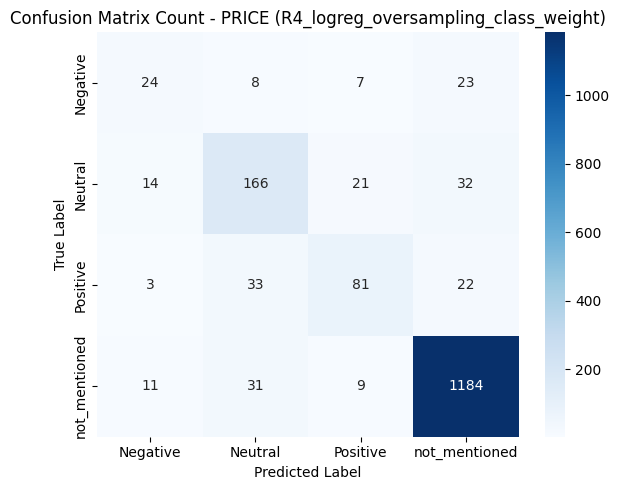

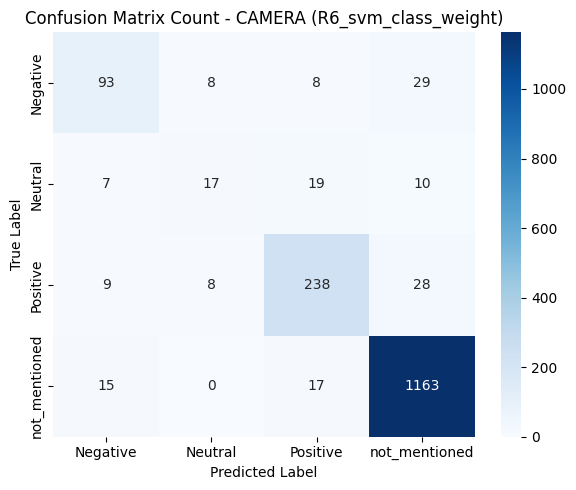

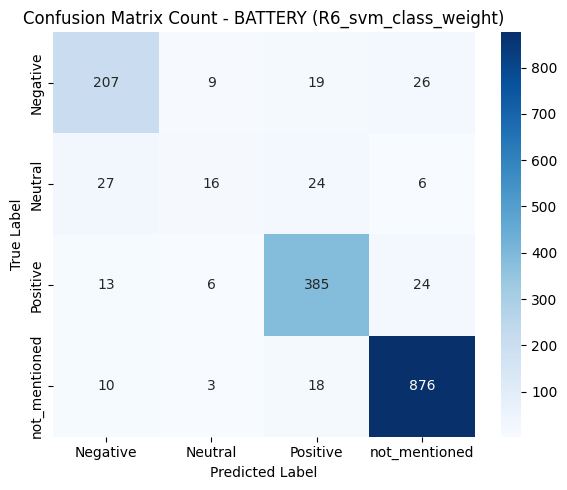

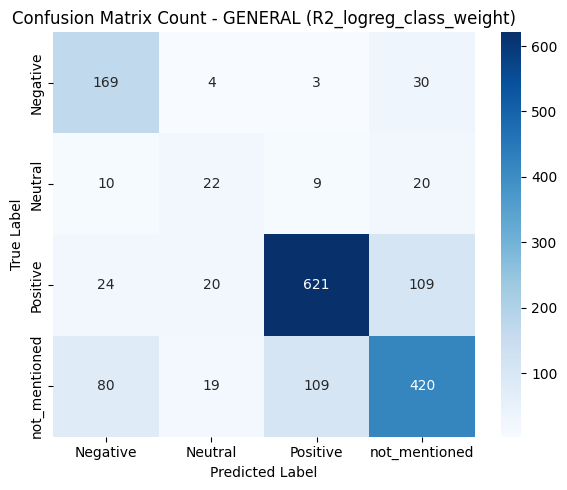

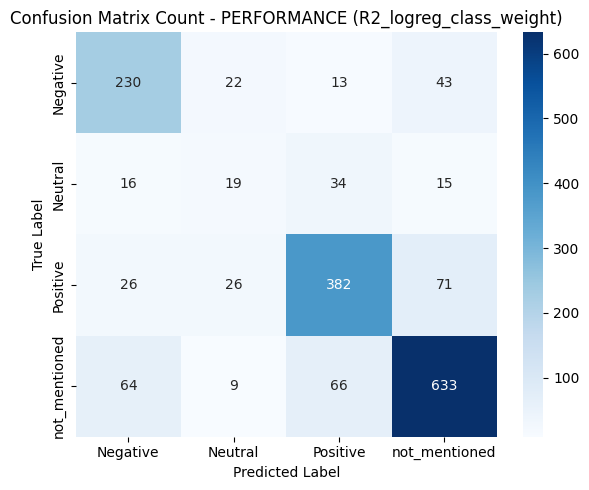

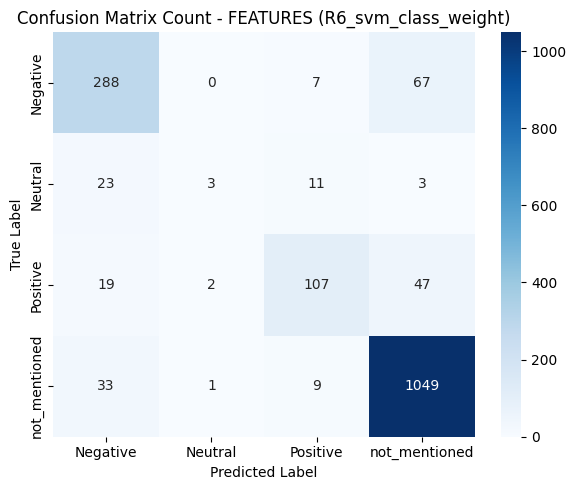

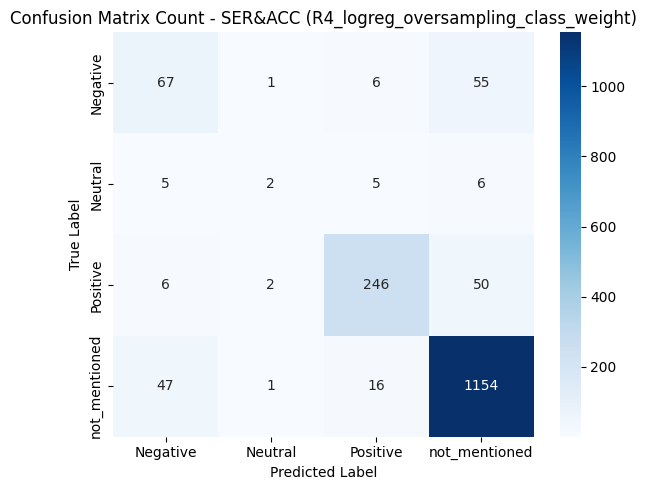

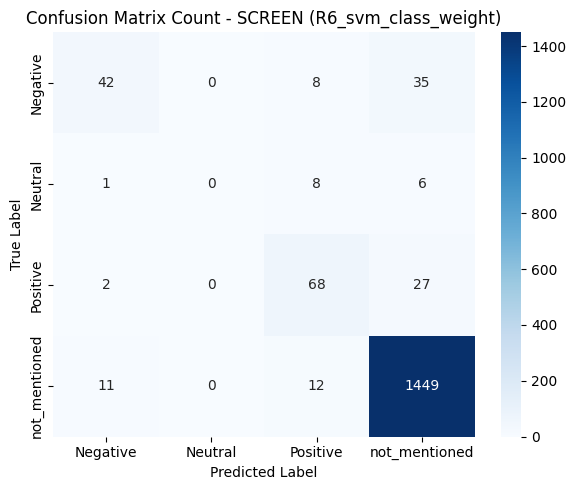

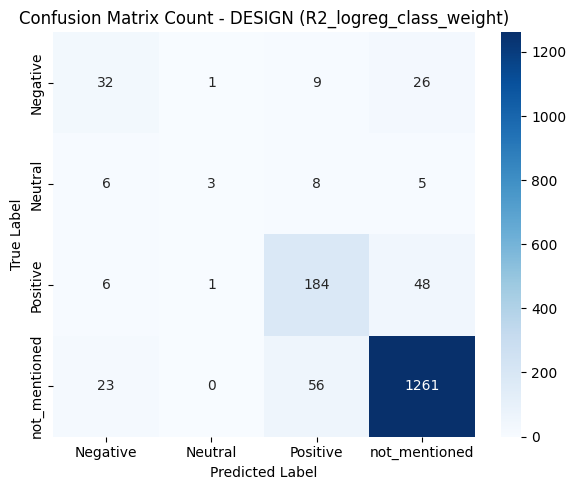

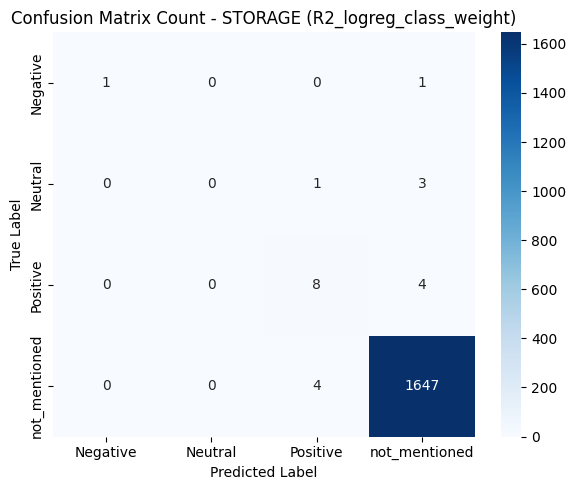

In [35]:
# =========================================================
# 6.9 CONFUSION MATRIX - RAW COUNT
# =========================================================

for _, row in baseline_best_df.iterrows():
    aspect = row["aspect"]
    best_round = row["best_round"]

    model = baseline_models[(aspect, best_round)]
    target_col = f"{aspect}_id"

    y_true = test_prepared[target_col]
    y_pred = model.predict(test_prepared["text_clean"])

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=label_ids
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Confusion Matrix Count - {aspect} ({best_round})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# 6.10 CONFUSION MATRIX - NORMALIZED

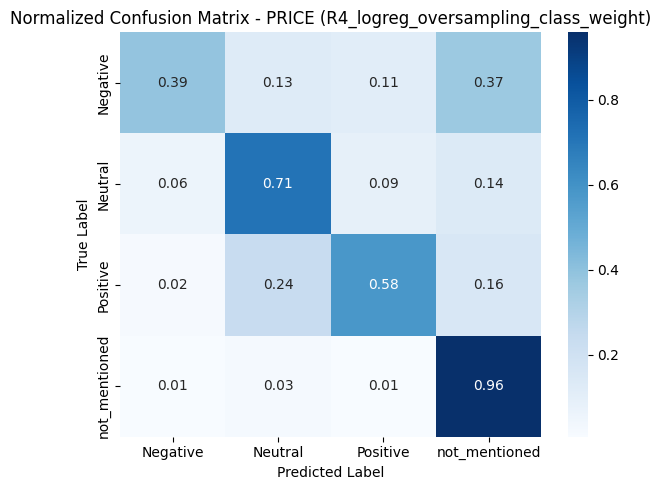

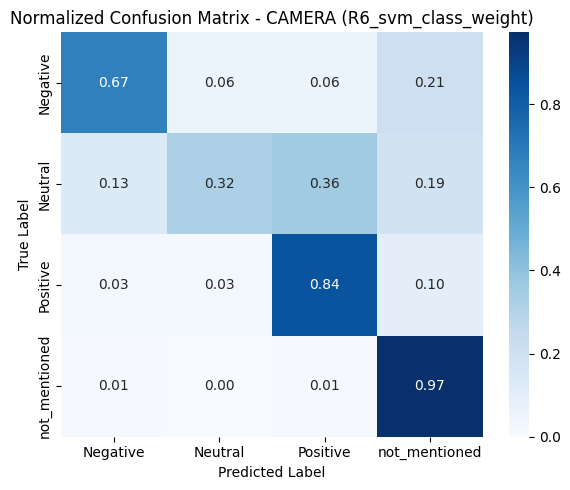

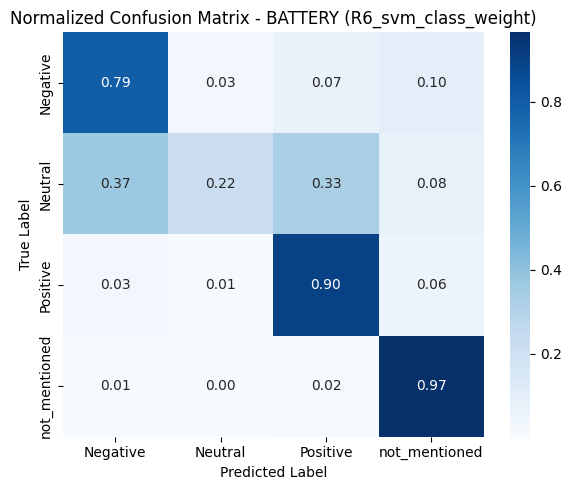

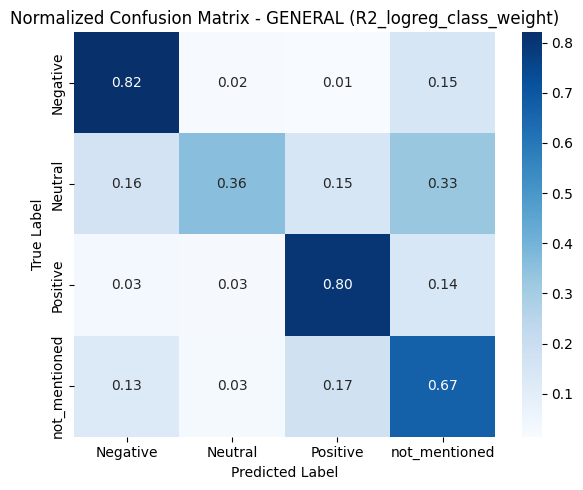

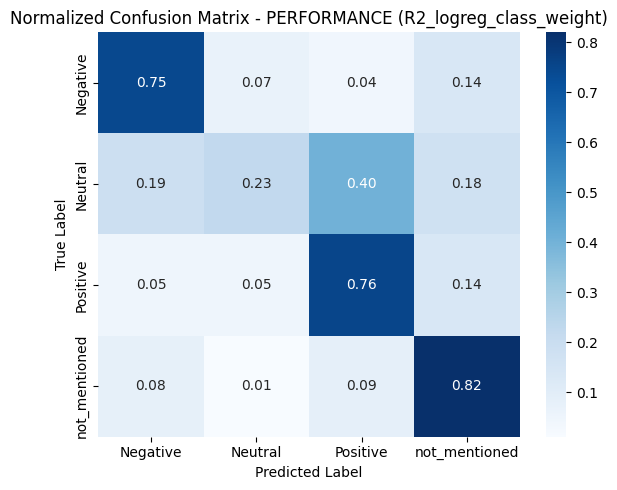

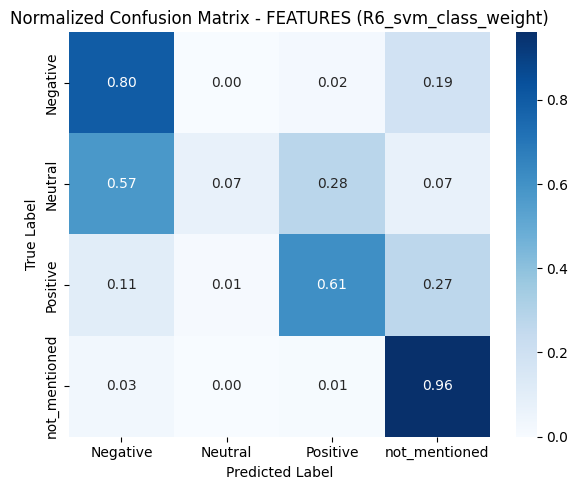

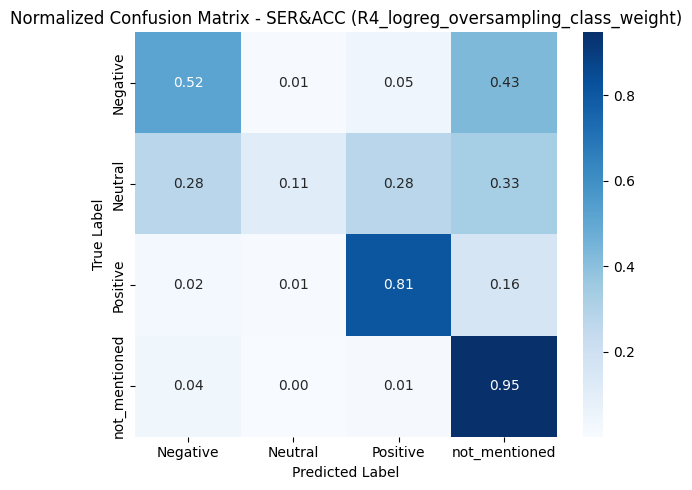

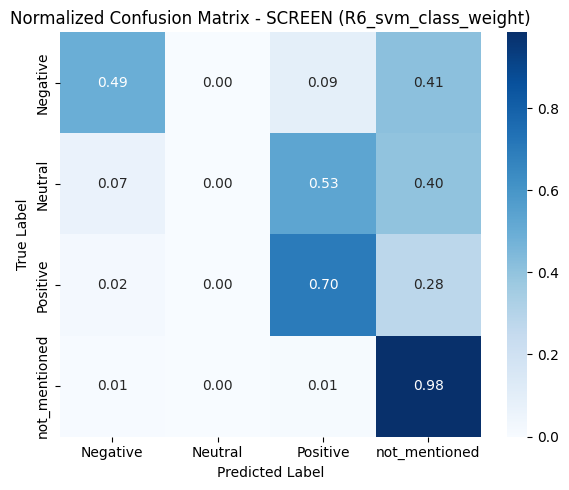

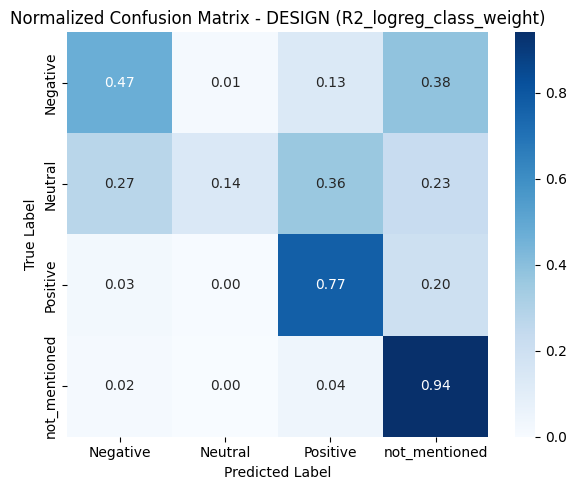

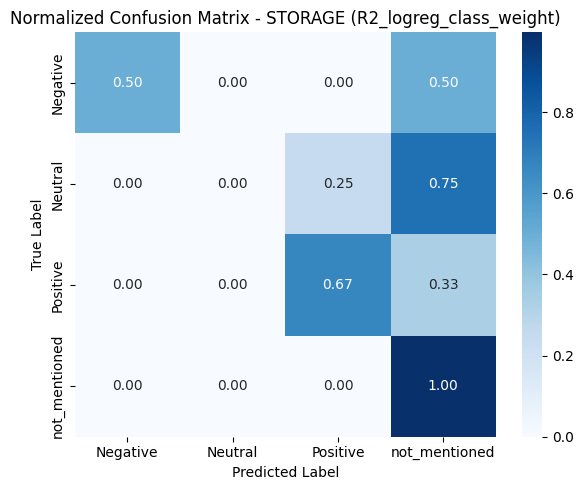

In [36]:
# =========================================================
# 6.10 CONFUSION MATRIX - NORMALIZED
# =========================================================

for _, row in baseline_best_df.iterrows():
    aspect = row["aspect"]
    best_round = row["best_round"]

    model = baseline_models[(aspect, best_round)]
    target_col = f"{aspect}_id"

    y_true = test_prepared[target_col]
    y_pred = model.predict(test_prepared["text_clean"])

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=label_ids,
        normalize="true"
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Normalized Confusion Matrix - {aspect} ({best_round})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [37]:
# =========================================================
# 6.11 VALIDATION VS TEST COMPARISON
# =========================================================

baseline_val_results = []

for _, row in baseline_best_df.iterrows():
    aspect = row["aspect"]
    best_round = row["best_round"]

    model = baseline_models[(aspect, best_round)]
    target_col = f"{aspect}_id"

    y_true = val_prepared[target_col]
    y_pred = model.predict(val_prepared["text_clean"])

    metrics = compute_baseline_metrics(y_true, y_pred)

    baseline_val_results.append({
        "aspect": aspect,
        "best_round": best_round,
        **metrics
    })

baseline_val_eval_df = pd.DataFrame(baseline_val_results)

baseline_compare_val_test = baseline_val_eval_df.merge(
    baseline_test_eval_df,
    on=["aspect", "best_round"],
    suffixes=("_val", "_test")
)

baseline_compare_val_test["macro_f1_gap"] = (
    baseline_compare_val_test["macro_f1_val"] -
    baseline_compare_val_test["macro_f1_test"]
)

baseline_compare_val_test

,aspect,best_round,accuracy_val,macro_precision_val,macro_recall_val,macro_f1_val,accuracy_test,macro_precision_test,macro_recall_test,macro_f1_test,macro_f1_gap
0,PRICE,R4_logreg_oversampling_class_weight,0.889754,0.768965,0.732550,0.749350,0.871780,0.696099,0.660245,0.676251,0.073099
1,CAMERA,R6_svm_class_weight,0.905932,0.755836,0.678718,0.705073,0.905333,0.763663,0.702220,0.726731,-0.021658
2,BATTERY,R6_svm_class_weight,0.865189,0.738078,0.691256,0.702595,0.889155,0.769795,0.719409,0.732998,-0.030403
3,GENERAL,R2_logreg_class_weight,0.757340,0.653597,0.685161,0.666894,0.738167,0.624488,0.663040,0.638904,0.027991
4,PERFORMANCE,R2_logreg_class_weight,0.756141,0.644025,0.654045,0.648137,0.757340,0.634237,0.637332,0.635270,0.012867
5,FEATURES,R6_svm_class_weight,0.849011,0.674684,0.574631,0.597421,0.866986,0.747888,0.610658,0.636654,-0.039232
6,SER&ACC,R4_logreg_oversampling_class_weight,0.886759,0.688493,0.591349,0.594334,0.880168,0.670671,0.596789,0.619108,-0.024774
7,SCREEN,R6_svm_class_weight,0.923907,0.820764,0.544607,0.584772,0.934092,0.603377,0.544881,0.567491,0.017281
8,DESIGN,R2_logreg_class_weight,0.891552,0.784272,0.567220,0.569548,0.886759,0.683653,0.579468,0.594819,-0.025271
9,STORAGE,R2_logreg_class_weight,0.988616,0.572730,0.443987,0.475906,0.992211,0.652638,0.541061,0.575759,-0.099853


# 6.8.3 Plot Accuracy vs Macro F1 on Test Set

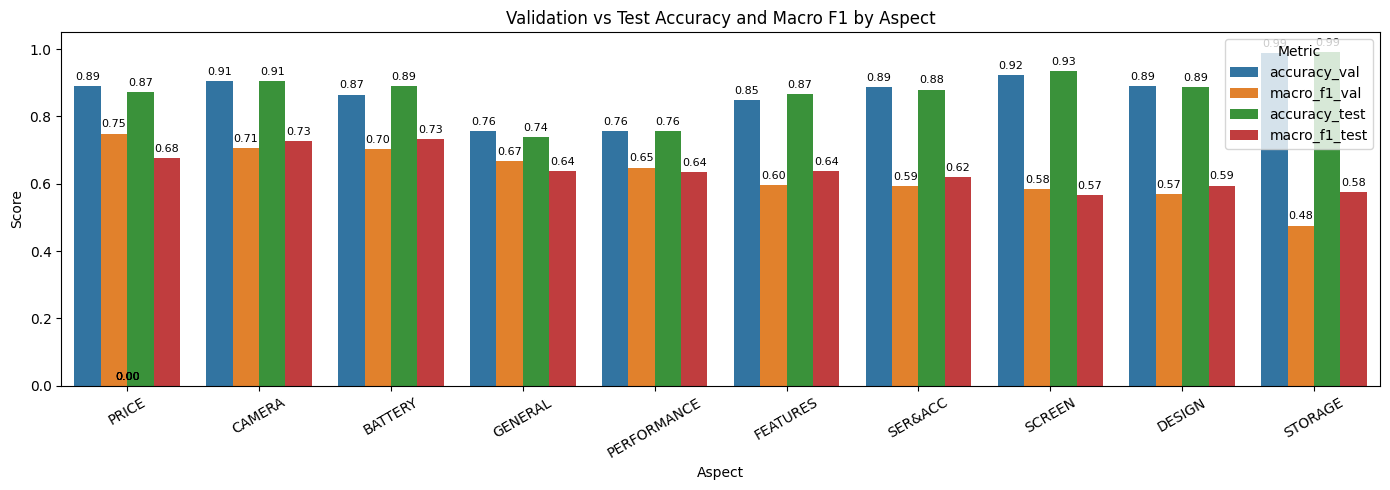

In [38]:
# =========================================================
# 6.12 PLOT VALIDATION VS TEST
# =========================================================

plot_df = baseline_compare_val_test.melt(
    id_vars=["aspect", "best_round"],
    value_vars=[
        "accuracy_val",
        "macro_f1_val",
        "accuracy_test",
        "macro_f1_test"
    ],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(14, 5))

ax = sns.barplot(
    data=plot_df,
    x="aspect",
    y="score",
    hue="metric"
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.title("Validation vs Test Accuracy and Macro F1 by Aspect")
plt.xlabel("Aspect")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1.05)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# 6.8.4 Save Final Evaluation Tables

In [39]:
# =========================================================
# 6.13 SAVE FINAL EVALUATION TABLES
# =========================================================

baseline_val_eval_df.to_csv(
    f"{RESULT_DIR}/baseline_best_model_validation_eval.csv",
    index=False
)

baseline_test_eval_df.to_csv(
    f"{RESULT_DIR}/baseline_best_model_test_eval.csv",
    index=False
)

baseline_compare_val_test.to_csv(
    f"{RESULT_DIR}/baseline_val_test_comparison.csv",
    index=False
)

baseline_test_eval_df

,aspect,best_round,accuracy,macro_precision,macro_recall,macro_f1
2,BATTERY,R6_svm_class_weight,0.889155,0.769795,0.719409,0.732998
1,CAMERA,R6_svm_class_weight,0.905333,0.763663,0.702220,0.726731
0,PRICE,R4_logreg_oversampling_class_weight,0.871780,0.696099,0.660245,0.676251
3,GENERAL,R2_logreg_class_weight,0.738167,0.624488,0.663040,0.638904
5,FEATURES,R6_svm_class_weight,0.866986,0.747888,0.610658,0.636654
4,PERFORMANCE,R2_logreg_class_weight,0.757340,0.634237,0.637332,0.635270
6,SER&ACC,R4_logreg_oversampling_class_weight,0.880168,0.670671,0.596789,0.619108
8,DESIGN,R2_logreg_class_weight,0.886759,0.683653,0.579468,0.594819
9,STORAGE,R2_logreg_class_weight,0.992211,0.652638,0.541061,0.575759
7,SCREEN,R6_svm_class_weight,0.934092,0.603377,0.544881,0.567491


# 7. PhoBERT Model

In [40]:
# !pip uninstall -y transformers huggingface_hub accelerate datasets tokenizers
# !rm -rf /usr/local/lib/python3.12/dist-packages/transformers*
# !rm -rf /usr/local/lib/python3.12/dist-packages/huggingface_hub*
# !rm -rf /usr/local/lib/python3.12/dist-packages/datasets*
# !rm -rf /usr/local/lib/python3.12/dist-packages/accelerate*
# !rm -rf /usr/local/lib/python3.12/dist-packages/tokenizers*

In [41]:
# !pip install --no-cache-dir -U transformers datasets accelerate tokenizers huggingface_hub -q

In [42]:
import transformers
import huggingface_hub
import datasets
import accelerate
import tokenizers

print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)
print("tokenizers:", tokenizers.__version__)

transformers: 5.0.0
huggingface_hub: 1.4.1
datasets: 4.8.3
accelerate: 1.12.0
tokenizers: 0.22.2


In [43]:
import os
import gc
import random
import numpy as np
import pandas as pd
import torch
from torch import nn

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    
MODEL_NAME = "vinai/phobert-base"

label_ids = [0, 1, 2, 3]
label_names = ["Negative", "Neutral", "Positive", "not_mentioned"]

PHOBERT_MODEL_DIR = f"{RESULT_DIR}/phobert_best_models"
PHOBERT_WEAK_MODEL_DIR = f"{RESULT_DIR}/phobert_weak_aspect_models"

os.makedirs(PHOBERT_MODEL_DIR, exist_ok=True)
os.makedirs(PHOBERT_WEAK_MODEL_DIR, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Tokenize function

In [44]:
def tokenize_function(examples):
    return tokenizer(
        examples["text_clean"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


In [45]:
def prepare_dataset(df, aspect):
    dataset = Dataset.from_pandas(
        df[["text_clean", f"{aspect}_id"]]
        .rename(columns={f"{aspect}_id": "label"})
    )

    dataset = dataset.map(tokenize_function, batched=True)
    dataset = dataset.remove_columns(["text_clean"])

    dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "label"]
    )

    return dataset

# Metric Function

In [46]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        labels=label_ids,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }


In [47]:
def compute_metrics_from_predictions(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=label_ids,
        average="macro",
        zero_division=0
    )

    return acc, p, r, f1

# Class weight

In [48]:
def get_class_weights(train_df, aspect, max_weight=None):
    target_col = f"{aspect}_id"
    y = train_df[target_col].values

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array(label_ids),
        y=y
    )

    if max_weight is not None:
        weights = np.minimum(weights, max_weight)

    return torch.tensor(weights, dtype=torch.float)

# Weighted Trainer

In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_fct(
            logits.view(-1, logits.shape[-1]),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

# Oversampling riêng cho STORAGE

In [50]:
# =========================================================
# STORAGE-SPECIFIC REBALANCING
# =========================================================

def rebalance_storage_train(
    train_df,
    aspect="STORAGE",
    sentiment_multiplier=8,
    min_sentiment_per_class=80,
    max_not_mentioned=1500,
    random_state=42
):
    target = f"{aspect}_id"
    df_temp = train_df.copy()

    parts = []

    for label in [0, 1, 2]:
        df_cls = df_temp[df_temp[target] == label]

        if len(df_cls) == 0:
            continue

        target_n = max(
            len(df_cls) * sentiment_multiplier,
            min_sentiment_per_class
        )

        sampled = df_cls.sample(
            n=target_n,
            replace=True,
            random_state=random_state
        )

        parts.append(sampled)

    df_nm = df_temp[df_temp[target] == 3]

    df_nm_sampled = df_nm.sample(
        n=min(max_not_mentioned, len(df_nm)),
        replace=False,
        random_state=random_state
    )

    parts.append(df_nm_sampled)

    df_rebalanced = pd.concat(parts, axis=0)
    df_rebalanced = df_rebalanced.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return df_rebalanced

# Train PhoBERT Single-task chính

In [51]:
def train_phobert_for_aspect(
    train_df,
    val_df,
    aspect,
    strategy="class_weight",
    num_epochs=4,
    batch_size=8,
    learning_rate=2e-5,
    output_dir=None,
    storage_multiplier=8,
    storage_max_nm=1500,
    max_class_weight=None
):
    print("=" * 80)
    print(f"Training PhoBERT - {aspect}")
    print(f"Strategy: {strategy}")

    if strategy == "storage_oversampling":
        train_used = rebalance_storage_train(
            train_df,
            aspect=aspect,
            sentiment_multiplier=storage_multiplier,
            max_not_mentioned=storage_max_nm,
            random_state=SEED
        )
    else:
        train_used = train_df.copy()

    print("\nTrain distribution:")
    print(train_used[f"{aspect}_id"].value_counts().sort_index())

    class_weights = get_class_weights(
        train_used,
        aspect,
        max_weight=max_class_weight
    )

    print("\nClass weights:")
    print(class_weights)

    train_ds = prepare_dataset(train_used, aspect)
    val_ds = prepare_dataset(val_df, aspect)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=4
    )

    if output_dir is None:
        output_dir = f"/tmp/phobert_best_{aspect}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        do_train=True,
        do_eval=True,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        report_to="none",
        seed=SEED
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()
    val_result = trainer.evaluate()

    return trainer, val_result

In [52]:
# =========================================================
# TRAIN MAIN PHOBERT MODELS
# - STORAGE dùng oversampling riêng
# - Các aspect khác dùng class_weight
# - Model lưu là best checkpoint theo validation macro_f1
# =========================================================

phobert_val_results = []
phobert_history = {}

for aspect in aspect_list:
    clear_gpu()

    if aspect == "STORAGE":
        trainer, val_result = train_phobert_for_aspect(
            train_prepared,
            val_prepared,
            aspect,
            strategy="storage_oversampling",
            num_epochs=4,
            batch_size=8,
            learning_rate=2e-5,
            output_dir=f"/tmp/phobert_best_{aspect}",
            storage_multiplier=8,
            storage_max_nm=1500,
            max_class_weight=15
        )
    else:
        trainer, val_result = train_phobert_for_aspect(
            train_prepared,
            val_prepared,
            aspect,
            strategy="class_weight",
            num_epochs=4,
            batch_size=8,
            learning_rate=2e-5,
            output_dir=f"/tmp/phobert_best_{aspect}",
            max_class_weight=None
        )

    phobert_history[aspect] = trainer.state.log_history

    phobert_val_results.append({
        "aspect": aspect,
        "accuracy": val_result["eval_accuracy"],
        "macro_precision": val_result["eval_macro_precision"],
        "macro_recall": val_result["eval_macro_recall"],
        "macro_f1": val_result["eval_macro_f1"]
    })

    save_path = f"{PHOBERT_MODEL_DIR}/phobert_{aspect}"
    os.makedirs(save_path, exist_ok=True)

    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    print(f"Saved best model: {save_path}")

    del trainer
    clear_gpu()

phobert_val_df = pd.DataFrame(phobert_val_results)
phobert_val_df.sort_values("macro_f1", ascending=False)

Training PhoBERT - SCREEN
Strategy: class_weight

Train distribution:
SCREEN_id
0     367
1      59
2     515
3    6843
Name: count, dtype: int64

Class weights:
tensor([ 5.3025, 32.9831,  3.7786,  0.2844])


Map:   0%|          | 0/7784 [00:00<?, ? examples/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best model: /kaggle/working/results/phobert_best_models/phobert_SER&ACC


,aspect,accuracy,macro_precision,macro_recall,macro_f1
3,BATTERY,0.911923,0.810029,0.825462,0.817225
7,PRICE,0.916117,0.788934,0.852304,0.814845
1,CAMERA,0.932894,0.787576,0.832119,0.808147
8,GENERAL,0.838226,0.752224,0.775221,0.760194
4,PERFORMANCE,0.819652,0.735297,0.790491,0.755637
2,FEATURES,0.869982,0.713210,0.752029,0.729725
6,DESIGN,0.938886,0.743271,0.715623,0.724935
9,SER&ACC,0.907130,0.654378,0.676888,0.663232
0,SCREEN,0.936489,0.577748,0.653438,0.610443
5,STORAGE,0.982025,0.449879,0.469936,0.456706


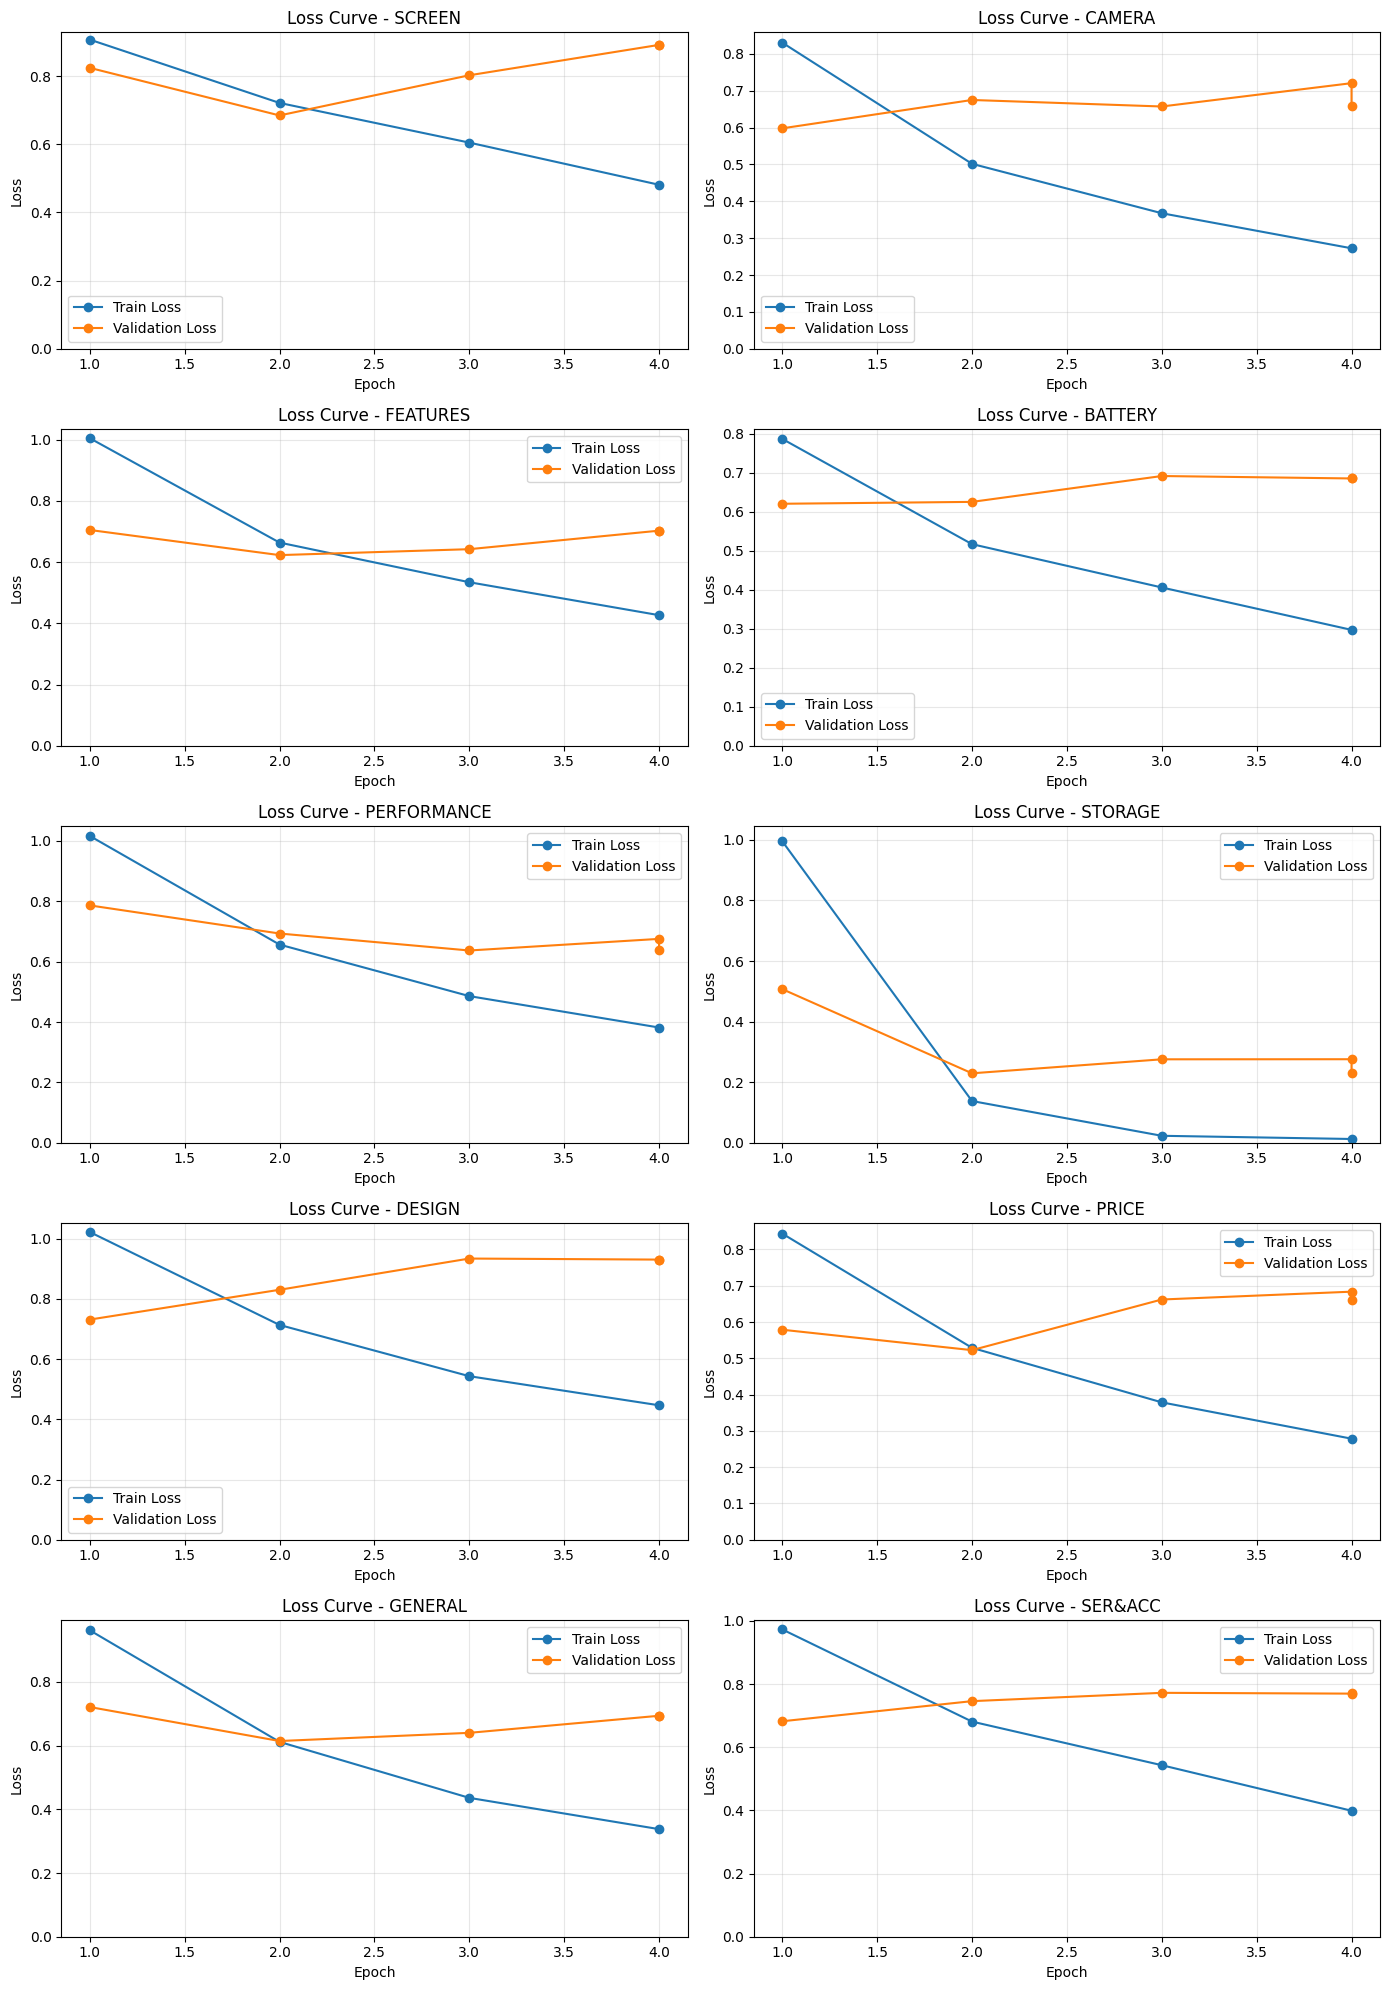

In [53]:
# =========================================================
# LOSS CURVES - 10 ASPECTS, 5 ROWS x 2 COLUMNS
# =========================================================

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, aspect in enumerate(aspect_list):
    history = phobert_history[aspect]

    train_epochs = []
    train_losses = []
    val_epochs = []
    val_losses = []

    for log in history:
        if "loss" in log and "epoch" in log:
            train_epochs.append(log["epoch"])
            train_losses.append(log["loss"])

        if "eval_loss" in log and "epoch" in log:
            val_epochs.append(log["epoch"])
            val_losses.append(log["eval_loss"])

    ax = axes[idx]

    ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
    ax.plot(val_epochs, val_losses, marker="o", label="Validation Loss")

    ax.set_title(f"Loss Curve - {aspect}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# =========================================================
# EVALUATE PHOBERT ON TEST SET
# =========================================================

def evaluate_phobert_model(model_path, test_df, aspect):
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    trainer = Trainer(
        model=model,
        compute_metrics=compute_metrics
    )

    test_ds = prepare_dataset(test_df, aspect)
    preds = trainer.predict(test_ds)

    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    acc, p, r, f1 = compute_metrics_from_predictions(y_true, y_pred)

    del trainer
    del model
    clear_gpu()

    return y_true, y_pred, acc, p, r, f1


phobert_test_results = []

for aspect in aspect_list:
    print("=" * 80)
    print(f"Test Evaluation - {aspect}")

    model_path = f"{PHOBERT_MODEL_DIR}/phobert_{aspect}"

    y_true, y_pred, acc, p, r, f1 = evaluate_phobert_model(
        model_path,
        test_prepared,
        aspect
    )

    phobert_test_results.append({
        "aspect": aspect,
        "accuracy": acc,
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision: {p:.4f}")
    print(f"Macro Recall: {r:.4f}")
    print(f"Macro F1: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=label_names,
        zero_division=0
    ))

phobert_test_df = pd.DataFrame(phobert_test_results)
phobert_test_df.sort_values("macro_f1", ascending=False)

Test Evaluation - SCREEN


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Accuracy: 0.9365
Macro Precision: 0.5738
Macro Recall: 0.6550
Macro F1: 0.6089

Classification Report:
               precision    recall  f1-score   support

     Negative       0.65      0.76      0.70        85
      Neutral       0.00      0.00      0.00        15
     Positive       0.66      0.90      0.76        97
not_mentioned       0.98      0.96      0.97      1472

     accuracy                           0.94      1669
    macro avg       0.57      0.66      0.61      1669
 weighted avg       0.94      0.94      0.94      1669

Test Evaluation - CAMERA


...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Accuracy: 0.8963
Macro Precision: 0.6438
Macro Recall: 0.6525
Macro F1: 0.6468

Classification Report:
               precision    recall  f1-score   support

     Negative       0.61      0.67      0.63       129
      Neutral       0.15      0.11      0.13        18
     Positive       0.87      0.90      0.89       304
not_mentioned       0.95      0.93      0.94      1218

     accuracy                           0.90      1669
    macro avg       0.64      0.65      0.65      1669
 weighted avg       0.90      0.90      0.90      1669



,aspect,accuracy,macro_precision,macro_recall,macro_f1
3,BATTERY,0.925105,0.836204,0.841374,0.837991
7,PRICE,0.920312,0.792326,0.842907,0.813819
1,CAMERA,0.938886,0.793942,0.828027,0.809657
2,FEATURES,0.890354,0.759116,0.796212,0.775595
4,PERFORMANCE,0.835231,0.741581,0.781932,0.757597
6,DESIGN,0.933493,0.801374,0.738407,0.756713
8,GENERAL,0.823247,0.732061,0.782531,0.748876
9,SER&ACC,0.896345,0.643777,0.652532,0.646843
0,SCREEN,0.936489,0.573837,0.655043,0.608905
5,STORAGE,0.990413,0.507273,0.665455,0.563679


# Improved PhoBERT for Weak Aspects

In [55]:
# =========================================================
# 8. IMPROVED PHOBERT FOR WEAK ASPECTS
# =========================================================

IMPROVED_MODEL_DIR = f"{RESULT_DIR}/phobert_improved_weak_aspects"
os.makedirs(IMPROVED_MODEL_DIR, exist_ok=True)

In [56]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = nn.CrossEntropyLoss(
            weight=self.alpha,
            reduction="none"
        )(logits, targets)

        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()

In [57]:
class ImprovedTrainer(Trainer):
    def __init__(self, class_weights=None, loss_type="focal", focal_gamma=1.5, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.loss_type = loss_type
        self.focal_gamma = focal_gamma

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.loss_type == "focal":
            loss_fct = FocalLoss(
                alpha=self.class_weights.to(logits.device),
                gamma=self.focal_gamma
            )
            loss = loss_fct(logits, labels)
        else:
            loss_fct = nn.CrossEntropyLoss(
                weight=self.class_weights.to(logits.device)
            )
            loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [58]:
def train_improved_phobert_for_aspect(
    train_df,
    val_df,
    aspect,
    num_epochs=5,
    batch_size=8,
    learning_rate=1e-5,
    max_class_weight=10,
    focal_gamma=1.5
):
    print("=" * 80)
    print(f"Improved PhoBERT - {aspect}")

    if aspect == "STORAGE":
        print("Strategy: storage oversampling + focal loss")
        train_used = rebalance_storage_train(
            train_df,
            aspect=aspect,
            sentiment_multiplier=8,
            min_sentiment_per_class=100,
            max_not_mentioned=1500,
            random_state=SEED
        )
    else:
        print("Strategy: focal loss + clipped class weight")
        train_used = train_df.copy()

    print("\nTrain distribution:")
    print(train_used[f"{aspect}_id"].value_counts().sort_index())

    class_weights = get_class_weights(
        train_used,
        aspect,
        max_weight=max_class_weight
    )

    train_ds = prepare_dataset(train_used, aspect)
    val_ds = prepare_dataset(val_df, aspect)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=4
    )

    output_dir = f"/tmp/phobert_improved_{aspect}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        do_train=True,
        do_eval=True,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        report_to="none",
        seed=SEED
    )

    trainer = ImprovedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        loss_type="focal",
        focal_gamma=focal_gamma,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()
    val_result = trainer.evaluate()

    save_path = f"{IMPROVED_MODEL_DIR}/phobert_improved_{aspect}"
    os.makedirs(save_path, exist_ok=True)

    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    return trainer, val_result, save_path

In [59]:
weak_aspects = ["STORAGE", "SCREEN", "SER&ACC", "DESIGN"]

improved_val_results = []
improved_model_paths = {}

for aspect in weak_aspects:
    clear_gpu()

    trainer, val_result, save_path = train_improved_phobert_for_aspect(
        train_prepared,
        val_prepared,
        aspect,
        num_epochs=5,
        batch_size=8,
        learning_rate=1e-5,
        max_class_weight=10,
        focal_gamma=1.5
    )

    improved_model_paths[aspect] = save_path

    improved_val_results.append({
        "aspect": aspect,
        "accuracy": val_result["eval_accuracy"],
        "macro_precision": val_result["eval_macro_precision"],
        "macro_recall": val_result["eval_macro_recall"],
        "macro_f1": val_result["eval_macro_f1"],
        "model_path": save_path
    })

    del trainer
    clear_gpu()

improved_val_df = pd.DataFrame(improved_val_results)
improved_val_df.sort_values("macro_f1", ascending=False)

Improved PhoBERT - STORAGE
Strategy: storage oversampling + focal loss

Train distribution:
STORAGE_id
0     144
1     100
2     464
3    1500
Name: count, dtype: int64


Map:   0%|          | 0/2208 [00:00<?, ? examples/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,aspect,accuracy,macro_precision,macro_recall,macro_f1,model_path
1,SCREEN,0.916717,0.619022,0.695894,0.623398,/kaggle/working/results/phobert_improved_weak_...
3,DESIGN,0.916717,0.640492,0.640536,0.623246,/kaggle/working/results/phobert_improved_weak_...
2,SER&ACC,0.860395,0.587733,0.657594,0.611678,/kaggle/working/results/phobert_improved_weak_...
0,STORAGE,0.950270,0.323659,0.475593,0.357373,/kaggle/working/results/phobert_improved_weak_...


In [60]:
improved_test_results = []

for aspect in weak_aspects:
    print("=" * 80)
    print(f"Improved Test Evaluation - {aspect}")

    model_path = improved_model_paths[aspect]

    y_true, y_pred, acc, p, r, f1 = evaluate_phobert_model(
        model_path,
        test_prepared,
        aspect
    )

    improved_test_results.append({
        "aspect": aspect,
        "accuracy": acc,
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "model_path": model_path
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")

    print(classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=label_names,
        zero_division=0
    ))

improved_test_df = pd.DataFrame(improved_test_results)
improved_test_df.sort_values("macro_f1", ascending=False)

Improved Test Evaluation - STORAGE


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Accuracy: 0.9617
Macro F1: 0.3835
               precision    recall  f1-score   support

     Negative       0.14      1.00      0.25         2
      Neutral       0.00      0.00      0.00         4
     Positive       0.19      0.83      0.30        12
not_mentioned       1.00      0.96      0.98      1651

     accuracy                           0.96      1669
    macro avg       0.33      0.70      0.38      1669
 weighted avg       0.99      0.96      0.97      1669

Improved Test Evaluation - SCREEN


...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Accuracy: 0.9119
Macro F1: 0.6131
               precision    recall  f1-score   support

     Negative       0.54      0.66      0.59        68
      Neutral       0.25      0.05      0.08        22
     Positive       0.79      0.87      0.83       239
not_mentioned       0.96      0.95      0.95      1340

     accuracy                           0.91      1669
    macro avg       0.63      0.63      0.61      1669
 weighted avg       0.91      0.91      0.91      1669



,aspect,accuracy,macro_precision,macro_recall,macro_f1,model_path
2,SER&ACC,0.878969,0.599743,0.648111,0.619688,/kaggle/working/results/phobert_improved_weak_...
1,SCREEN,0.904733,0.612042,0.686622,0.614351,/kaggle/working/results/phobert_improved_weak_...
3,DESIGN,0.911923,0.634290,0.631805,0.613115,/kaggle/working/results/phobert_improved_weak_...
0,STORAGE,0.961654,0.331384,0.699551,0.383485,/kaggle/working/results/phobert_improved_weak_...


In [61]:
compare_improved_df = phobert_val_df[
    phobert_val_df["aspect"].isin(weak_aspects)
][[
    "aspect",
    "accuracy",
    "macro_f1"
]].rename(columns={
    "accuracy": "accuracy_old_val",
    "macro_f1": "macro_f1_old_val"
}).merge(
    improved_val_df[[
        "aspect",
        "accuracy",
        "macro_f1"
    ]].rename(columns={
        "accuracy": "accuracy_improved_val",
        "macro_f1": "macro_f1_improved_val"
    }),
    on="aspect"
).merge(
    phobert_test_df[
        phobert_test_df["aspect"].isin(weak_aspects)
    ][[
        "aspect",
        "accuracy",
        "macro_f1"
    ]].rename(columns={
        "accuracy": "accuracy_old_test",
        "macro_f1": "macro_f1_old_test"
    }),
    on="aspect"
).merge(
    improved_test_df[[
        "aspect",
        "accuracy",
        "macro_f1"
    ]].rename(columns={
        "accuracy": "accuracy_improved_test",
        "macro_f1": "macro_f1_improved_test"
    }),
    on="aspect"
)

compare_improved_df["val_gain"] = (
    compare_improved_df["macro_f1_improved_val"] -
    compare_improved_df["macro_f1_old_val"]
)

compare_improved_df["test_gain"] = (
    compare_improved_df["macro_f1_improved_test"] -
    compare_improved_df["macro_f1_old_test"]
)

compare_improved_df

,aspect,accuracy_old_val,macro_f1_old_val,accuracy_improved_val,macro_f1_improved_val,accuracy_old_test,macro_f1_old_test,accuracy_improved_test,macro_f1_improved_test,val_gain,test_gain
0,SCREEN,0.936489,0.610443,0.916717,0.623398,0.936489,0.608905,0.904733,0.614351,0.012955,0.005446
1,STORAGE,0.982025,0.456706,0.950270,0.357373,0.990413,0.563679,0.961654,0.383485,-0.099333,-0.180193
2,DESIGN,0.938886,0.724935,0.916717,0.623246,0.933493,0.756713,0.911923,0.613115,-0.101689,-0.143598
3,SER&ACC,0.907130,0.663232,0.860395,0.611678,0.896345,0.646843,0.878969,0.619688,-0.051554,-0.027155


In [62]:
final_phobert_model_paths = {}

for aspect in aspect_list:
    old_path = f"{PHOBERT_MODEL_DIR}/phobert_{aspect}"

    if aspect in weak_aspects:
        old_val_f1 = phobert_val_df.loc[
            phobert_val_df["aspect"] == aspect,
            "macro_f1"
        ].values[0]

        improved_val_f1 = improved_val_df.loc[
            improved_val_df["aspect"] == aspect,
            "macro_f1"
        ].values[0]

        if improved_val_f1 > old_val_f1:
            final_phobert_model_paths[aspect] = improved_model_paths[aspect]
        else:
            final_phobert_model_paths[aspect] = old_path
    else:
        final_phobert_model_paths[aspect] = old_path

final_phobert_model_paths

{'SCREEN': '/kaggle/working/results/phobert_improved_weak_aspects/phobert_improved_SCREEN',
 'CAMERA': '/kaggle/working/results/phobert_best_models/phobert_CAMERA',
 'FEATURES': '/kaggle/working/results/phobert_best_models/phobert_FEATURES',
 'BATTERY': '/kaggle/working/results/phobert_best_models/phobert_BATTERY',
 'PERFORMANCE': '/kaggle/working/results/phobert_best_models/phobert_PERFORMANCE',
 'STORAGE': '/kaggle/working/results/phobert_best_models/phobert_STORAGE',
 'DESIGN': '/kaggle/working/results/phobert_best_models/phobert_DESIGN',
 'PRICE': '/kaggle/working/results/phobert_best_models/phobert_PRICE',
 'GENERAL': '/kaggle/working/results/phobert_best_models/phobert_GENERAL',
 'SER&ACC': '/kaggle/working/results/phobert_best_models/phobert_SER&ACC'}

In [63]:
phobert_final_val_results = []
phobert_final_test_results = []

for aspect in aspect_list:
    model_path = final_phobert_model_paths[aspect]

    selected_version = (
        "Improved PhoBERT"
        if aspect in weak_aspects and model_path == improved_model_paths.get(aspect)
        else "Single-task PhoBERT"
    )

    y_true, y_pred, acc, p, r, f1 = evaluate_phobert_model(
        model_path,
        val_prepared,
        aspect
    )

    phobert_final_val_results.append({
        "aspect": aspect,
        "selected_phobert_version": selected_version,
        "accuracy": acc,
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "model_path": model_path
    })

    y_true, y_pred, acc, p, r, f1 = evaluate_phobert_model(
        model_path,
        test_prepared,
        aspect
    )

    phobert_final_test_results.append({
        "aspect": aspect,
        "selected_phobert_version": selected_version,
        "accuracy": acc,
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "model_path": model_path
    })

phobert_final_val_df = pd.DataFrame(phobert_final_val_results)
phobert_final_test_df = pd.DataFrame(phobert_final_test_results)

phobert_final_val_df.sort_values("macro_f1", ascending=False)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



In [64]:
# =========================================================
# COMPARE BASELINE VS FINAL PHOBERT
# Final PhoBERT = single-task cũ hoặc improved, chọn theo validation
# =========================================================

compare_baseline_phobert_val_df = baseline_val_eval_df[[
    "aspect", "accuracy", "macro_precision", "macro_recall", "macro_f1"
]].rename(columns={
    "accuracy": "accuracy_baseline_val",
    "macro_precision": "macro_precision_baseline_val",
    "macro_recall": "macro_recall_baseline_val",
    "macro_f1": "macro_f1_baseline_val"
}).merge(
    phobert_final_val_df[[
        "aspect", "selected_phobert_version",
        "accuracy", "macro_precision", "macro_recall", "macro_f1"
    ]].rename(columns={
        "accuracy": "accuracy_phobert_val",
        "macro_precision": "macro_precision_phobert_val",
        "macro_recall": "macro_recall_phobert_val",
        "macro_f1": "macro_f1_phobert_val"
    }),
    on="aspect"
)

compare_baseline_phobert_val_df["selected_model_by_val"] = np.where(
    compare_baseline_phobert_val_df["macro_f1_phobert_val"] >=
    compare_baseline_phobert_val_df["macro_f1_baseline_val"],
    "PhoBERT",
    "Baseline"
)

compare_baseline_phobert_val_df["val_macro_f1_gain"] = (
    compare_baseline_phobert_val_df["macro_f1_phobert_val"] -
    compare_baseline_phobert_val_df["macro_f1_baseline_val"]
)

compare_baseline_phobert_val_df.sort_values(
    "macro_f1_phobert_val",
    ascending=False
)

,aspect,accuracy_baseline_val,macro_precision_baseline_val,macro_recall_baseline_val,macro_f1_baseline_val,selected_phobert_version,accuracy_phobert_val,macro_precision_phobert_val,macro_recall_phobert_val,macro_f1_phobert_val,selected_model_by_val,val_macro_f1_gain
2,BATTERY,0.865189,0.738078,0.691256,0.702595,Single-task PhoBERT,0.911923,0.810029,0.825462,0.817225,PhoBERT,0.114630
0,PRICE,0.889754,0.768965,0.732550,0.749350,Single-task PhoBERT,0.916117,0.788934,0.852304,0.814845,PhoBERT,0.065495
1,CAMERA,0.905932,0.755836,0.678718,0.705073,Single-task PhoBERT,0.932894,0.787576,0.832119,0.808147,PhoBERT,0.103073
3,GENERAL,0.757340,0.653597,0.685161,0.666894,Single-task PhoBERT,0.838226,0.752224,0.775221,0.760194,PhoBERT,0.093300
4,PERFORMANCE,0.756141,0.644025,0.654045,0.648137,Single-task PhoBERT,0.819652,0.735297,0.790491,0.755637,PhoBERT,0.107500
5,FEATURES,0.849011,0.674684,0.574631,0.597421,Single-task PhoBERT,0.869982,0.713210,0.752029,0.729725,PhoBERT,0.132304
8,DESIGN,0.891552,0.784272,0.567220,0.569548,Single-task PhoBERT,0.938886,0.743271,0.715623,0.724935,PhoBERT,0.155387
6,SER&ACC,0.886759,0.688493,0.591349,0.594334,Single-task PhoBERT,0.907130,0.654378,0.676888,0.663232,PhoBERT,0.068898
7,SCREEN,0.923907,0.820764,0.544607,0.584772,Improved PhoBERT,0.916717,0.619022,0.695894,0.623398,PhoBERT,0.038626
9,STORAGE,0.988616,0.572730,0.443987,0.475906,Single-task PhoBERT,0.982025,0.449879,0.469936,0.456706,Baseline,-0.019200


In [65]:
# =========================================================
# TEST COMPARISON: BASELINE VS FINAL PHOBERT
# =========================================================

compare_baseline_phobert_test_df = baseline_test_eval_df[[
    "aspect", "accuracy", "macro_precision", "macro_recall", "macro_f1"
]].rename(columns={
    "accuracy": "accuracy_baseline_test",
    "macro_precision": "macro_precision_baseline_test",
    "macro_recall": "macro_recall_baseline_test",
    "macro_f1": "macro_f1_baseline_test"
}).merge(
    phobert_final_test_df[[
        "aspect", "selected_phobert_version",
        "accuracy", "macro_precision", "macro_recall", "macro_f1"
    ]].rename(columns={
        "accuracy": "accuracy_phobert_test",
        "macro_precision": "macro_precision_phobert_test",
        "macro_recall": "macro_recall_phobert_test",
        "macro_f1": "macro_f1_phobert_test"
    }),
    on="aspect"
)

compare_baseline_phobert_test_df["test_macro_f1_gain"] = (
    compare_baseline_phobert_test_df["macro_f1_phobert_test"] -
    compare_baseline_phobert_test_df["macro_f1_baseline_test"]
)

compare_baseline_phobert_test_df.sort_values(
    "macro_f1_phobert_test",
    ascending=False
)

,aspect,accuracy_baseline_test,macro_precision_baseline_test,macro_recall_baseline_test,macro_f1_baseline_test,selected_phobert_version,accuracy_phobert_test,macro_precision_phobert_test,macro_recall_phobert_test,macro_f1_phobert_test,test_macro_f1_gain
0,BATTERY,0.889155,0.769795,0.719409,0.732998,Single-task PhoBERT,0.925105,0.836204,0.841374,0.837991,0.104993
2,PRICE,0.871780,0.696099,0.660245,0.676251,Single-task PhoBERT,0.920312,0.792326,0.842907,0.813819,0.137568
1,CAMERA,0.905333,0.763663,0.702220,0.726731,Single-task PhoBERT,0.938886,0.793942,0.828027,0.809657,0.082926
4,FEATURES,0.866986,0.747888,0.610658,0.636654,Single-task PhoBERT,0.890354,0.759116,0.796212,0.775595,0.138941
5,PERFORMANCE,0.757340,0.634237,0.637332,0.635270,Single-task PhoBERT,0.835231,0.741581,0.781932,0.757597,0.122327
7,DESIGN,0.886759,0.683653,0.579468,0.594819,Single-task PhoBERT,0.933493,0.801374,0.738407,0.756713,0.161894
3,GENERAL,0.738167,0.624488,0.663040,0.638904,Single-task PhoBERT,0.823247,0.732061,0.782531,0.748876,0.109972
6,SER&ACC,0.880168,0.670671,0.596789,0.619108,Single-task PhoBERT,0.896345,0.643777,0.652532,0.646843,0.027735
9,SCREEN,0.934092,0.603377,0.544881,0.567491,Improved PhoBERT,0.904733,0.612042,0.686622,0.614351,0.046860
8,STORAGE,0.992211,0.652638,0.541061,0.575759,Single-task PhoBERT,0.990413,0.507273,0.665455,0.563679,-0.012080


In [66]:
# =========================================================
# SUMMARY: BASELINE VS FINAL PHOBERT
# =========================================================

summary_phobert = pd.DataFrame({
    "model": ["Baseline", "Final PhoBERT"],
    "average_macro_f1": [
        compare_baseline_phobert_test_df["macro_f1_baseline_test"].mean(),
        compare_baseline_phobert_test_df["macro_f1_phobert_test"].mean()
    ],
    "average_accuracy": [
        compare_baseline_phobert_test_df["accuracy_baseline_test"].mean(),
        compare_baseline_phobert_test_df["accuracy_phobert_test"].mean()
    ]
})

summary_phobert

,model,average_macro_f1,average_accuracy
0,Baseline,0.640398,0.872199
1,Final PhoBERT,0.732512,0.905812


In [67]:
# =========================================================
# FINAL TEST RESULT BASED ON VALIDATION SELECTION
# Chọn Baseline hoặc Final PhoBERT theo validation, rồi lấy test
# =========================================================

final_selected_test_results = []

for _, row in compare_baseline_phobert_val_df.iterrows():
    aspect = row["aspect"]
    selected_model = row["selected_model_by_val"]

    test_row = compare_baseline_phobert_test_df[
        compare_baseline_phobert_test_df["aspect"] == aspect
    ].iloc[0]

    if selected_model == "PhoBERT":
        test_accuracy = test_row["accuracy_phobert_test"]
        test_macro_precision = test_row["macro_precision_phobert_test"]
        test_macro_recall = test_row["macro_recall_phobert_test"]
        test_macro_f1 = test_row["macro_f1_phobert_test"]
        selected_phobert_version = test_row["selected_phobert_version"]
    else:
        test_accuracy = test_row["accuracy_baseline_test"]
        test_macro_precision = test_row["macro_precision_baseline_test"]
        test_macro_recall = test_row["macro_recall_baseline_test"]
        test_macro_f1 = test_row["macro_f1_baseline_test"]
        selected_phobert_version = None

    final_selected_test_results.append({
        "aspect": aspect,
        "selected_model_by_val": selected_model,
        "selected_phobert_version": selected_phobert_version,
        "test_accuracy": test_accuracy,
        "test_macro_precision": test_macro_precision,
        "test_macro_recall": test_macro_recall,
        "test_macro_f1": test_macro_f1
    })

final_selected_test_df = pd.DataFrame(final_selected_test_results)

final_selected_test_df = final_selected_test_df.sort_values(
    "test_macro_f1",
    ascending=False
)

final_selected_test_df

,aspect,selected_model_by_val,selected_phobert_version,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
2,BATTERY,PhoBERT,Single-task PhoBERT,0.925105,0.836204,0.841374,0.837991
0,PRICE,PhoBERT,Single-task PhoBERT,0.920312,0.792326,0.842907,0.813819
1,CAMERA,PhoBERT,Single-task PhoBERT,0.938886,0.793942,0.828027,0.809657
5,FEATURES,PhoBERT,Single-task PhoBERT,0.890354,0.759116,0.796212,0.775595
4,PERFORMANCE,PhoBERT,Single-task PhoBERT,0.835231,0.741581,0.781932,0.757597
8,DESIGN,PhoBERT,Single-task PhoBERT,0.933493,0.801374,0.738407,0.756713
3,GENERAL,PhoBERT,Single-task PhoBERT,0.823247,0.732061,0.782531,0.748876
6,SER&ACC,PhoBERT,Single-task PhoBERT,0.896345,0.643777,0.652532,0.646843
7,SCREEN,PhoBERT,Improved PhoBERT,0.904733,0.612042,0.686622,0.614351
9,STORAGE,Baseline,None,0.992211,0.652638,0.541061,0.575759


Normalized Confusion Matrix - Final PhoBERT - SCREEN


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


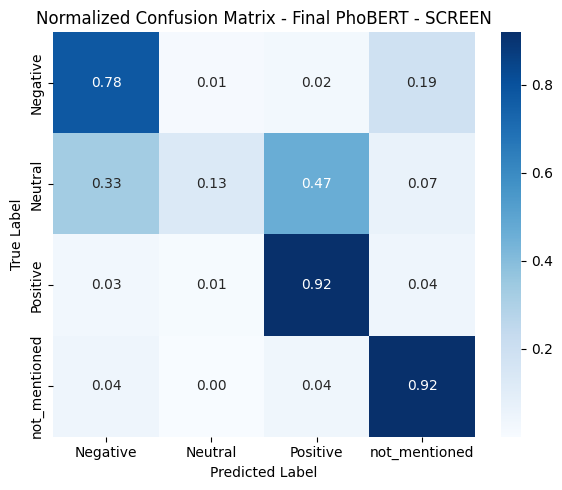

Normalized Confusion Matrix - Final PhoBERT - CAMERA


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


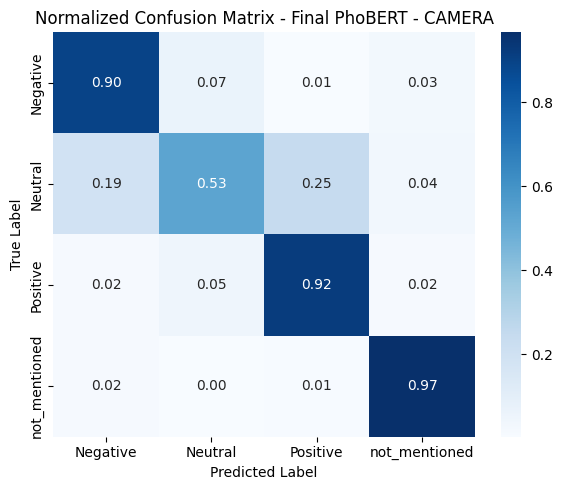

Normalized Confusion Matrix - Final PhoBERT - FEATURES


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


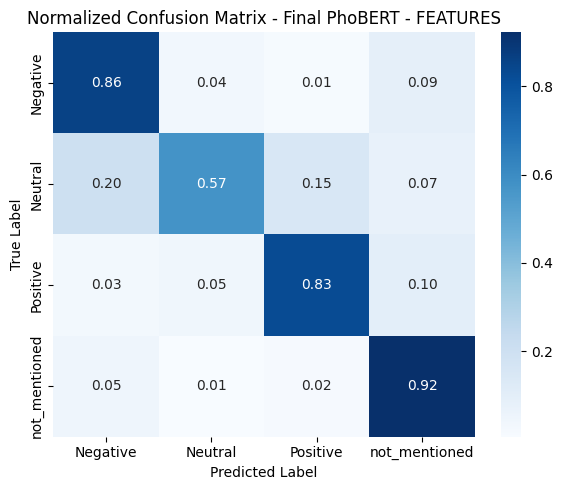

Normalized Confusion Matrix - Final PhoBERT - BATTERY


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


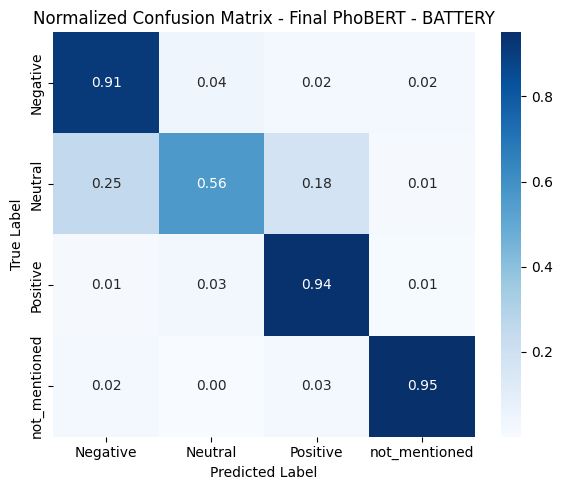

Normalized Confusion Matrix - Final PhoBERT - PERFORMANCE


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


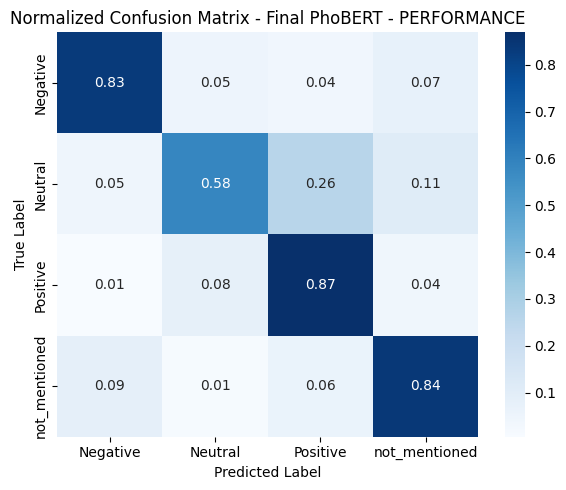

Normalized Confusion Matrix - Final PhoBERT - STORAGE


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


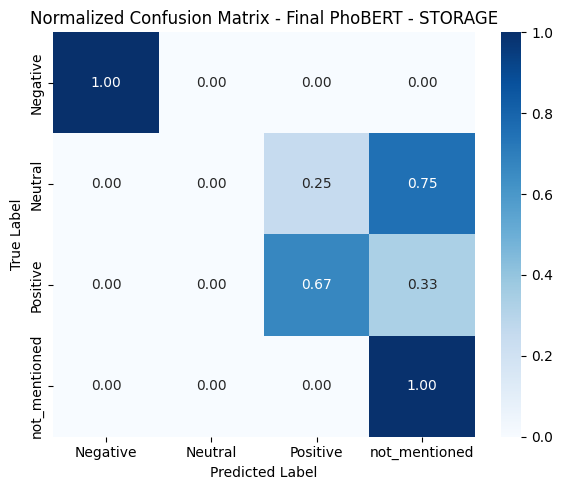

Normalized Confusion Matrix - Final PhoBERT - DESIGN


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


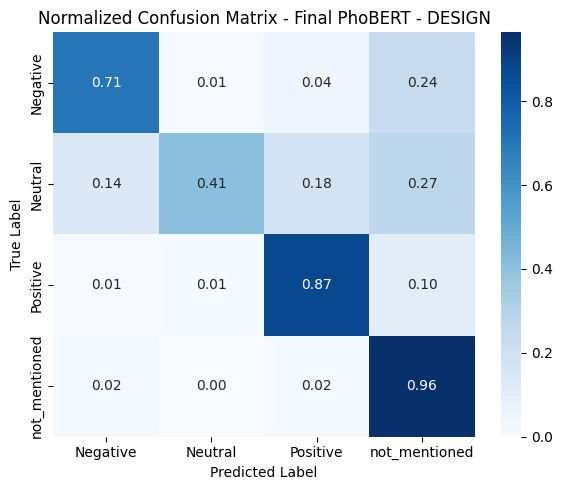

Normalized Confusion Matrix - Final PhoBERT - PRICE


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


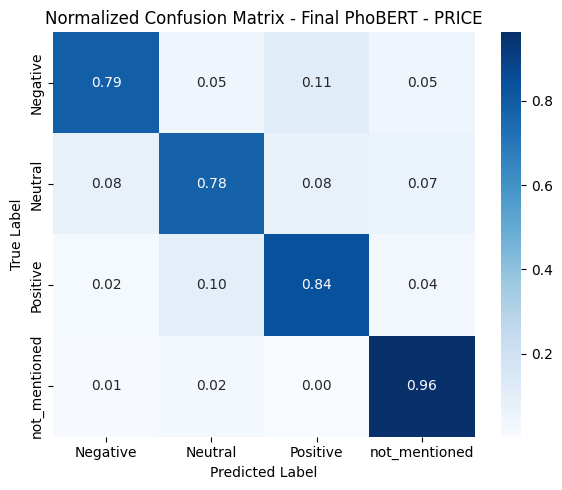

Normalized Confusion Matrix - Final PhoBERT - GENERAL


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


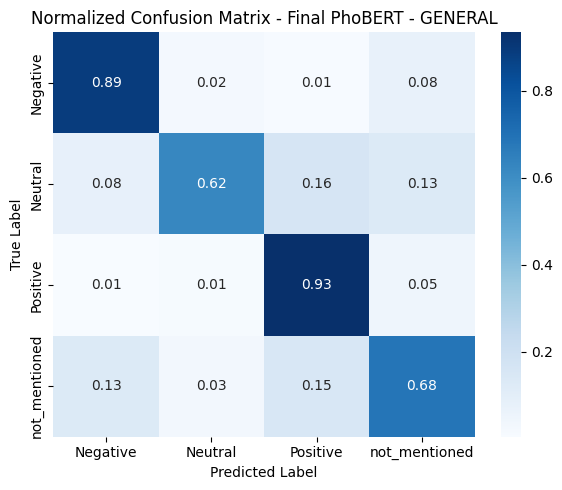

Normalized Confusion Matrix - Final PhoBERT - SER&ACC


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1669 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


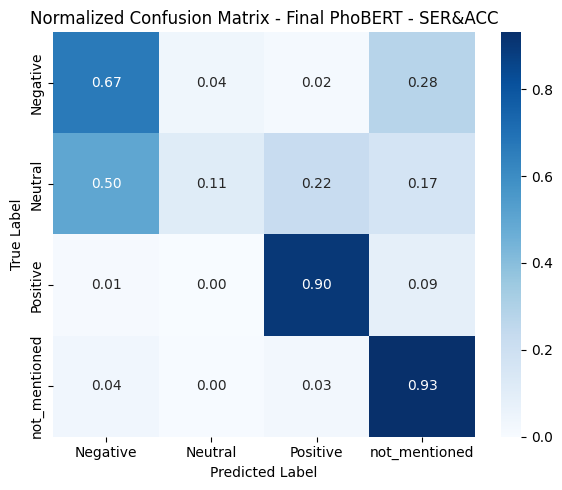

In [68]:
# =========================================================
# FINAL PHOBERT CONFUSION MATRICES
# dùng final_phobert_model_paths, không dùng model cũ trực tiếp
# =========================================================

for aspect in aspect_list:
    print("=" * 80)
    print(f"Normalized Confusion Matrix - Final PhoBERT - {aspect}")

    model_path = final_phobert_model_paths[aspect]

    y_true, y_pred, acc, p, r, f1 = evaluate_phobert_model(
        model_path,
        test_prepared,
        aspect
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=label_ids,
        normalize="true"
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Normalized Confusion Matrix - Final PhoBERT - {aspect}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [69]:
# =========================================================
# SAVE FINAL RESULTS
# =========================================================

phobert_val_df.to_csv(
    f"{RESULT_DIR}/phobert_single_validation_results.csv",
    index=False
)

phobert_test_df.to_csv(
    f"{RESULT_DIR}/phobert_single_test_results.csv",
    index=False
)

phobert_final_val_df.to_csv(
    f"{RESULT_DIR}/phobert_final_validation_results.csv",
    index=False
)

phobert_final_test_df.to_csv(
    f"{RESULT_DIR}/phobert_final_test_results.csv",
    index=False
)

compare_baseline_phobert_val_df.to_csv(
    f"{RESULT_DIR}/baseline_vs_final_phobert_validation_comparison.csv",
    index=False
)

compare_baseline_phobert_test_df.to_csv(
    f"{RESULT_DIR}/baseline_vs_final_phobert_test_comparison.csv",
    index=False
)

final_selected_test_df.to_csv(
    f"{RESULT_DIR}/final_selected_by_validation_test_results.csv",
    index=False
)

summary_phobert.to_csv(
    f"{RESULT_DIR}/baseline_vs_final_phobert_summary.csv",
    index=False
)

print("Saved final PhoBERT comparison results.")

Saved final PhoBERT comparison results.


# MULTI-TASK